<center><h1>1-ab: Introduction to Neural Networks</h1></center>

<center><h2><a href="https://rdfia.github.io/">Course link</a></h2></center>

# Warning :
# Do "File -> Save a copy in Drive" before you start modifying the notebook, otherwise your modifications will not be saved.


In [14]:
# !wget https://github.com/rdfia/rdfia.github.io/raw/master/data/2-ab.zip
# !unzip -j 2-ab.zip
# !wget https://github.com/rdfia/rdfia.github.io/raw/master/code/2-ab/utils-data.py

## MOUBARAK Carine 21314682
## ZHANG Zhile 21201131

In [1]:
import math
import torch
from torch.autograd import Variable
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from utils_data import * 
# %run 'C:\Users\User\Desktop\RDFIA\TME1\utils-data.py'

# Part 1 : Forward and backward passes "by hands"

In [2]:
def init_params(nx, nh, ny):
    """
    nx, nh, ny: integers
    out params: dictionnary
    """
    params = {}

    # fill values for Wh, Wy, bh, by

    params["Wh"] = torch.randn(nh,nx) * 0.3
    params["Wy"] = torch.randn(ny,nh) * 0.3
    params["bh"] = torch.randn(nh)
    params["by"] = torch.randn(ny)

    return params

In [3]:
def forward(params, X):
    """
    params: dictionnary
    X: (n_batch, dimension) --> (n_batch, nx)
    Wh (nh,nx)
    """
    bsize = X.size(0)
    nh = params['Wh'].size(0)
    ny = params['Wy'].size(0)
    outputs = {}

    # fill values for X, htilde, h, ytilde, yhat

    outputs["X"] = X
    outputs["htilde"] = torch.mm(X, params["Wh"].t()) + params["bh"].repeat(bsize, 1)
    outputs["h"] = torch.tanh(outputs["htilde"])
    outputs["ytilde"] = torch.mm(outputs["h"], params["Wy"].t()) + params["by"].repeat(bsize, 1)
    outputs["yhat"] = torch.softmax(outputs["ytilde"], dim=1)


    return outputs['yhat'], outputs

In [78]:
def loss_accuracy(Yhat, Y):


    L = -torch.mean(torch.sum(Y * torch.log(Yhat) ) )
    _, indYhat = torch.max(Yhat, 1)
    _, indY = torch.max(Y, 1)
    acc = (torch.sum(indYhat == indY).float() / Y.size(0)) * 100 # in percentage


    return L, acc

In [79]:
def backward(params, outputs, Y):
    bsize = Y.shape[0]
    grads = {}

    # fill values for Wy, Wh, by, bh

    # print("outputs['yhat'] shape:", outputs["yhat"].shape)
    # print("Y shape:", Y.shape)
    # print("params['Wy'] shape:", params["Wy"].shape)
    # print("outputs['h'] shape:", outputs["h"].shape)
    # print("outputs['X'] shape:", outputs["X"].shape)

    grads["Wy"] = torch.mm((outputs["yhat"] - Y).t(), outputs["h"])
    # print("Shape after (outputs['yhat'] - Y).mm(params['Wy']):", (outputs["yhat"] - Y).mm(params["Wy"]).shape)
    # print("Shape of (1 - outputs['h']**2):", (1 - outputs["h"]**2).shape)
    # print("Shape of (1 - outputs['h']**2):", (1 - outputs["h"]**2).t().shape)

    grads["Wh"] = torch.mm(((outputs["yhat"] - Y).mm(params["Wy"])) * (1 - outputs["h"]**2).t(), outputs["X"]) 
    grads["by"] = torch.sum(outputs["yhat"] - Y, 0).t()
    grads["bh"] = torch.sum(((outputs["yhat"] - Y).mm(params["Wy"])) * (1 - outputs["h"]**2),0).t()

    # print("grads['Wy'] shape:", grads["Wy"].shape)
    # print("grads['Wh'] shape:", grads["Wh"].shape)
    # print("grads['by'] shape:", grads["by"].shape)
    # print("grads['bh'] shape:", grads["bh"].shape)
    
    return grads

In [6]:
def sgd(params, grads, eta):

    # update the params values

    params["Wh"] = params["Wh"] - eta * grads["Wh"]
    params["Wy"] = params["Wy"] - eta * grads["Wy"]
    params["bh"] = params["bh"] - eta * grads["bh"]
    params["by"] = params["by"] - eta * grads["by"]


    return params

## Global learning procedure "by hands"

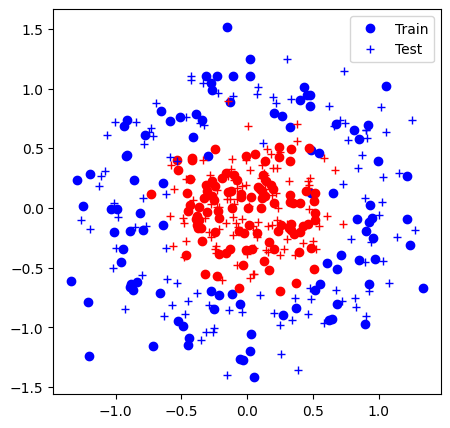

<Figure size 640x480 with 0 Axes>

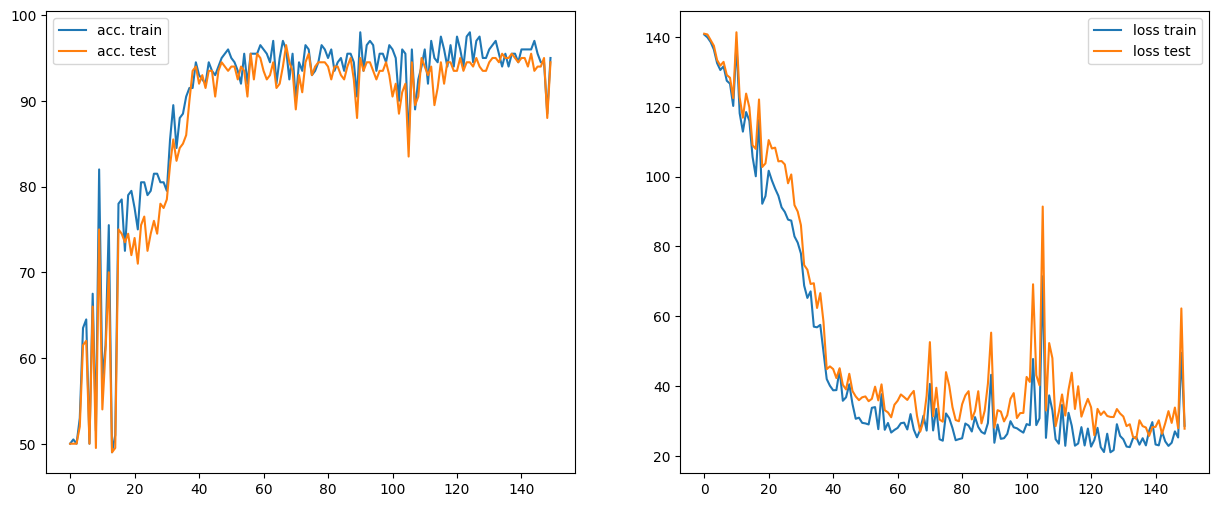

In [27]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
eta = 0.03

params = init_params(nx, nh, ny)

curves = [[],[], [], []]

# epoch
for iteration in range(150):

    # permute
    perm = np.random.permutation(N)
    Xtrain = data.Xtrain[perm, :]
    Ytrain = data.Ytrain[perm, :]

    # batches
    for j in range(N // Nbatch):

        indsBatch = range(j * Nbatch, (j+1) * Nbatch)
        X = Xtrain[indsBatch, :]
        Y = Ytrain[indsBatch, :]

        # write the optimization algorithm on the batch (X,Y)
        # using the functions: forward, loss_accuracy, backward, sgd

        Yhat, outputs = forward(params, X)
        L, acc = loss_accuracy(Yhat, Y)
        grads = backward(params, outputs, Y)
        params = sgd(params, grads, eta)




    Yhat_train, _ = forward(params, data.Xtrain)
    Yhat_test, _ = forward(params, data.Xtest)
    Ltrain, acctrain = loss_accuracy(Yhat_train, data.Ytrain)
    Ltest, acctest = loss_accuracy(Yhat_test, data.Ytest)
    # Ygrid, _ = forward(params, data.Xgrid)

    # title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
    # print(title)
    # data.plot_data_with_grid(Ygrid, title)

    curves[0].append(acctrain)
    curves[1].append(acctest)
    curves[2].append(Ltrain)
    curves[3].append(Ltest)

# fig = plt.figure()
# plt.plot(curves[0], label="acc. train")
# plt.plot(curves[1], label="acc. test")
# plt.plot(curves[2], label="loss train")
# plt.plot(curves[3], label="loss test")
# plt.legend()
# plt.show()

# split the plots of acc and loss
fig = plt.figure()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)

plt.plot(curves[0], label="acc. train")
plt.plot(curves[1], label="acc. test")
plt.legend()
plt.subplot(1,2,2)
plt.plot(curves[2], label="loss train")
plt.plot(curves[3], label="loss test")
plt.legend()

plt.show()

## Influence of learning rate

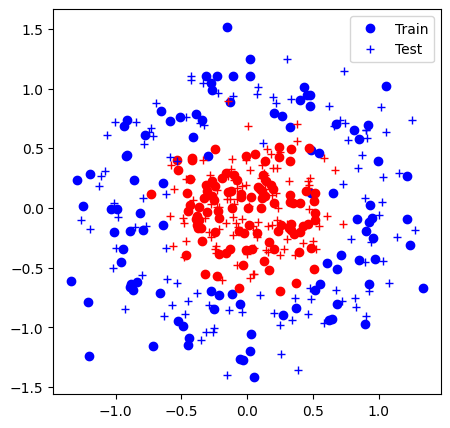

<Figure size 640x480 with 0 Axes>

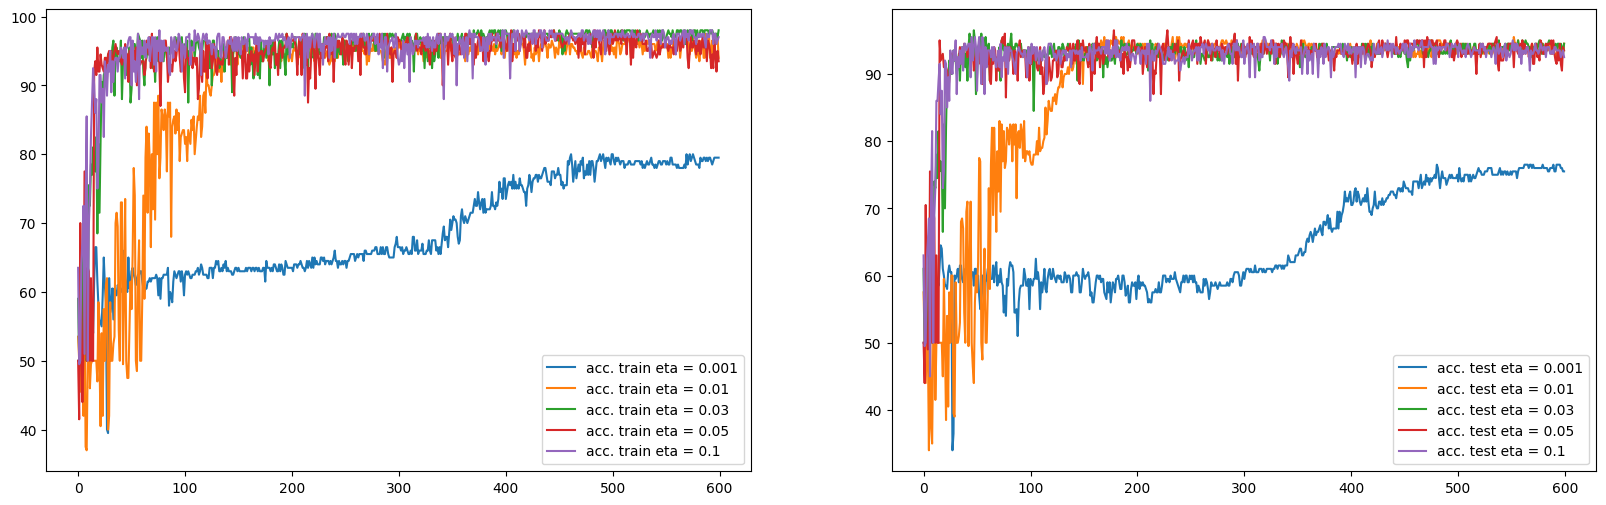

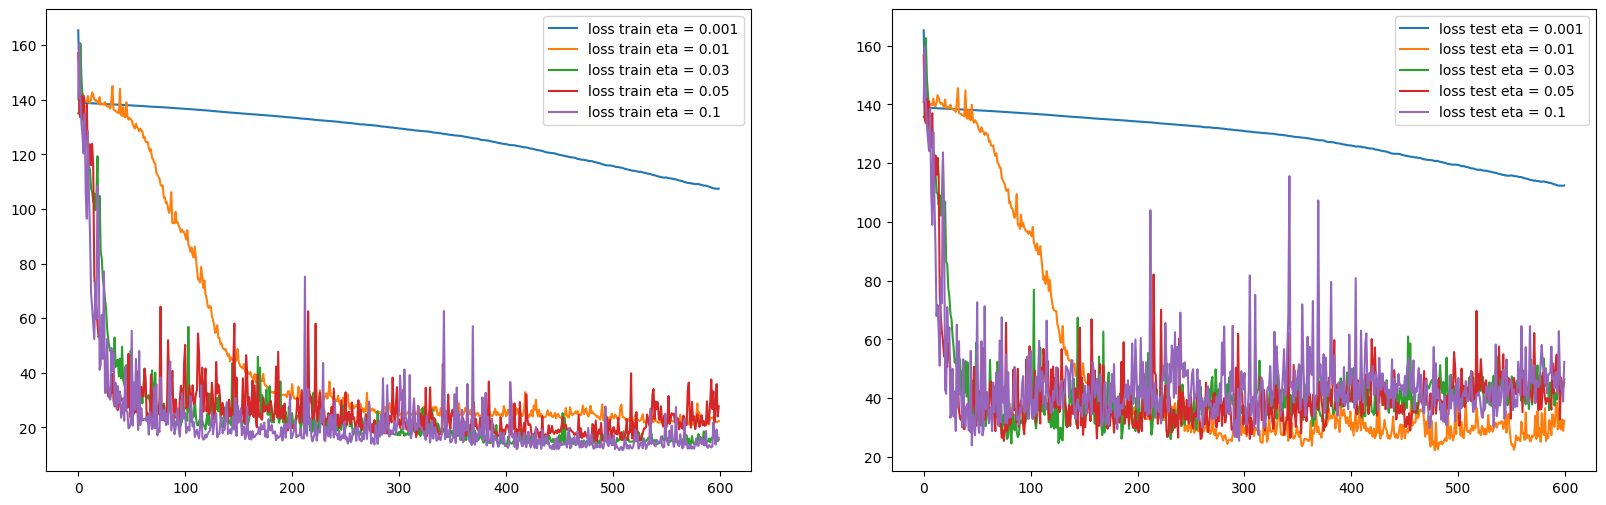

In [28]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_eta = [0.001,0.01,0.03,0.05,0.1]

params = init_params(nx, nh, ny)

curves = {eta: [[], [], [], []] for eta in l_eta}

for eta in l_eta:
    params = init_params(nx, nh, ny)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat, outputs = forward(params, X)
            L, acc = loss_accuracy(Yhat, Y)
            grads = backward(params, outputs, Y)
            params = sgd(params, grads, eta)




        Yhat_train, _ = forward(params, data.Xtrain)
        Yhat_test, _ = forward(params, data.Xtest)
        Ltrain, acctrain = loss_accuracy(Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[eta][0].append(acctrain)
        curves[eta][1].append(acctest)
        curves[eta][2].append(Ltrain)
        curves[eta][3].append(Ltest)

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][0], label="acc. train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][1], label="acc. test eta = {}".format(eta))
plt.legend()

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][2], label="loss train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][3], label="loss test eta = {}".format(eta))
plt.legend()

plt.show()




## Influence of batch size

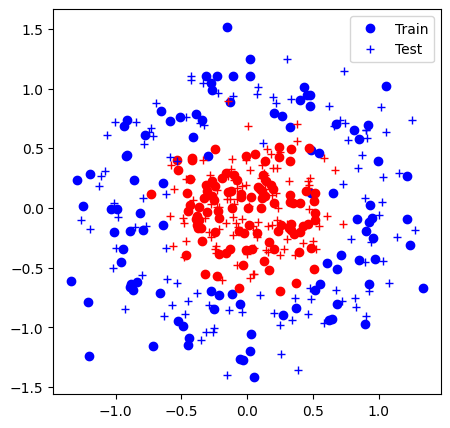

<Figure size 640x480 with 0 Axes>

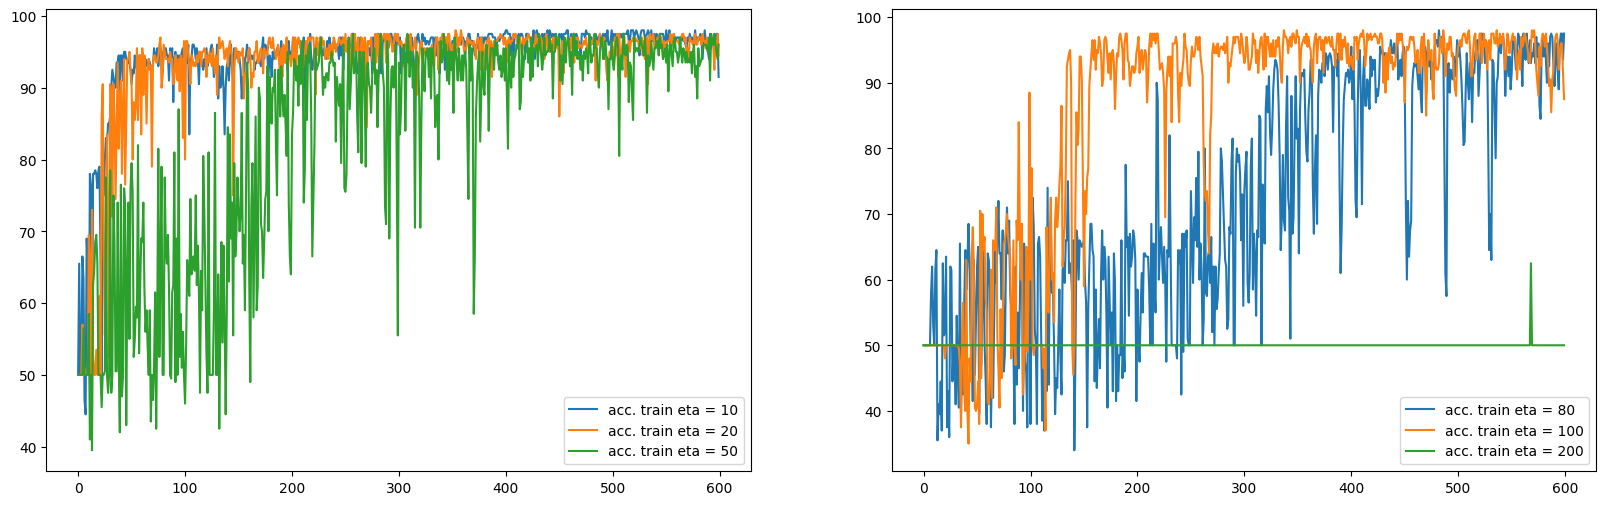

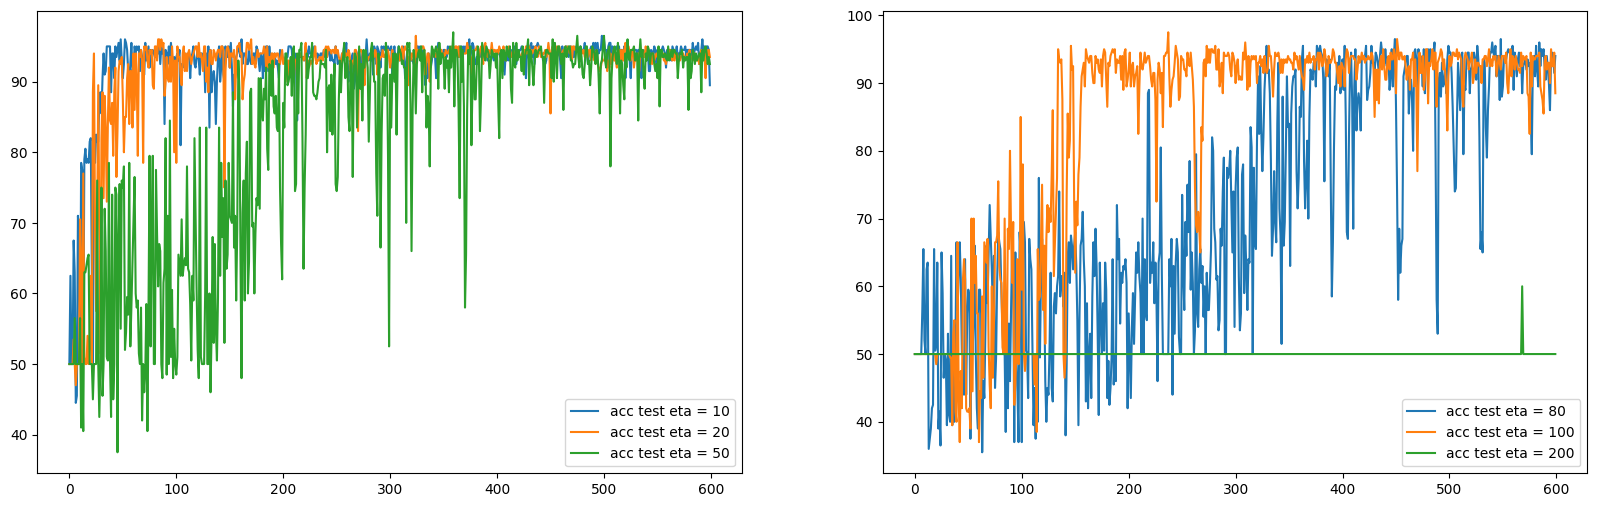

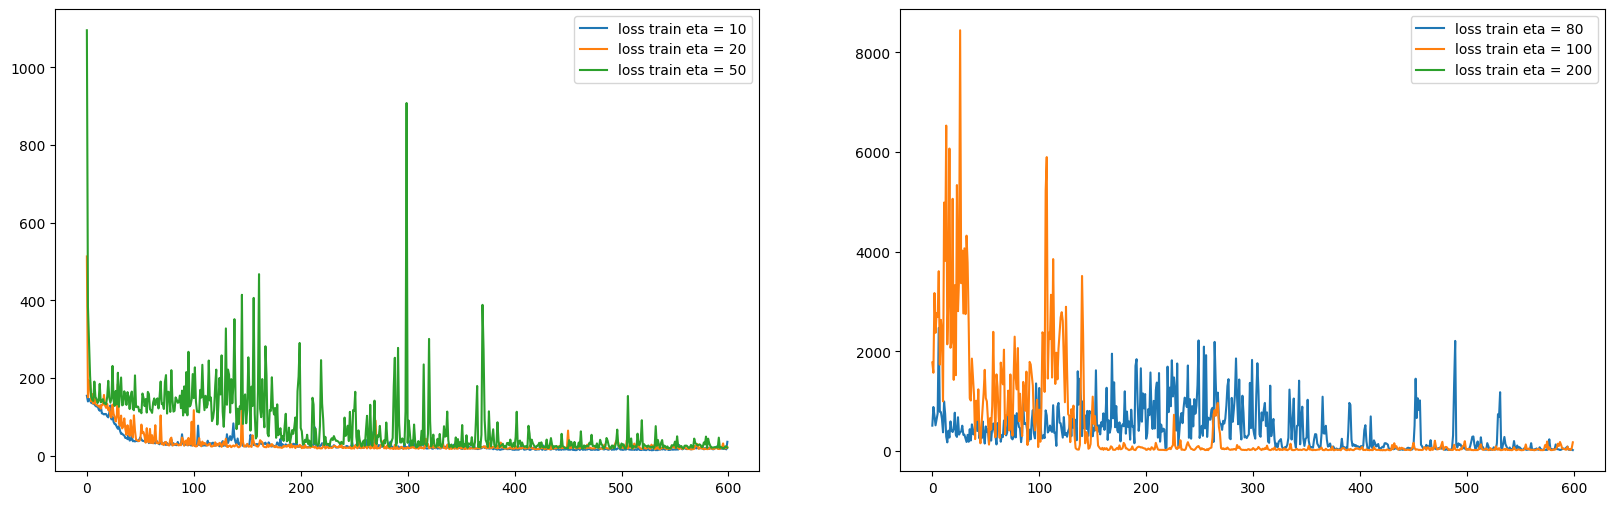

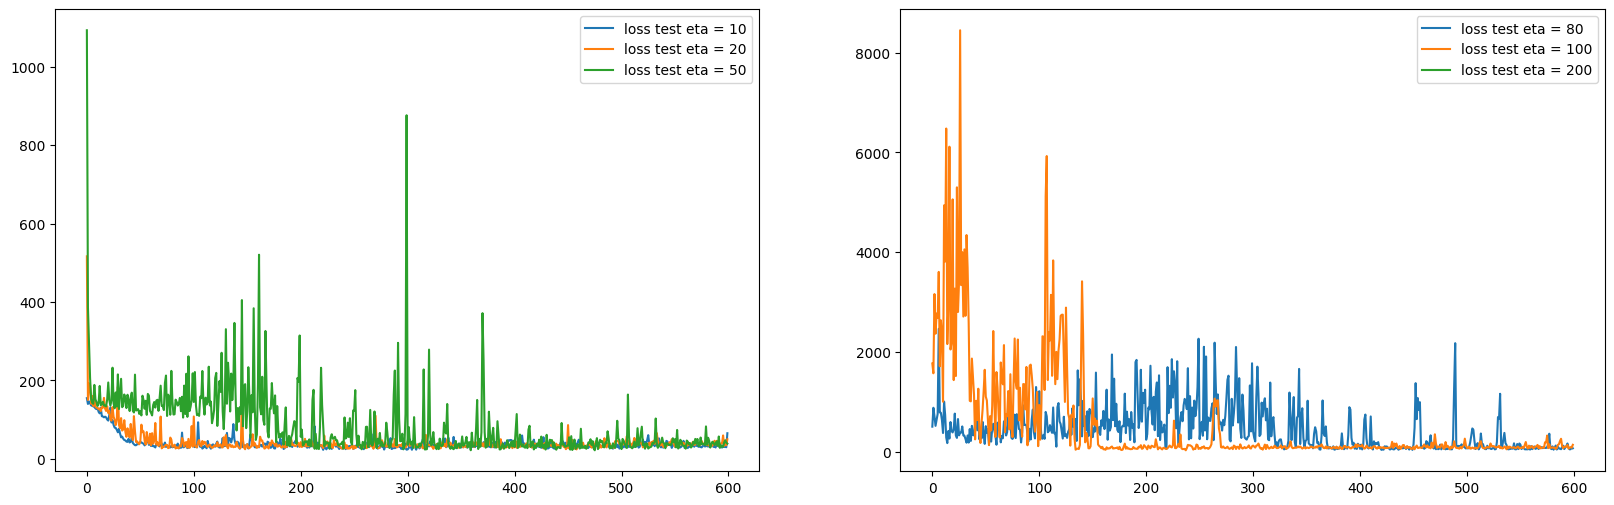

In [33]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
eta = 0.03
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_batch = [10, 20, 50, 80, 100,200]


curves = {Nbatch: [[], [], [], []] for Nbatch in l_batch}

for Nbatch in l_batch:
    params = init_params(nx, Nbatch, ny)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat, outputs = forward(params, X)
            L, acc = loss_accuracy(Yhat, Y)
            grads = backward(params, outputs, Y)
            params = sgd(params, grads, eta)




        Yhat_train, _ = forward(params, data.Xtrain)
        Yhat_test, _ = forward(params, data.Xtest)
        Ltrain, acctrain = loss_accuracy(Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[Nbatch][0].append(acctrain)
        curves[Nbatch][1].append(acctest)
        curves[Nbatch][2].append(Ltrain)
        curves[Nbatch][3].append(Ltest)

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
    if Nbatch != 100 and Nbatch != 200 and Nbatch != 80:
        plt.plot(curves[Nbatch][0], label="acc. train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
    if Nbatch == 100 or Nbatch == 200 or Nbatch == 80:
        plt.plot(curves[Nbatch][0], label="acc. train eta = {}".format(Nbatch))
plt.legend()


plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
    if Nbatch != 100 and Nbatch != 200 and Nbatch != 80:
        plt.plot(curves[Nbatch][1], label="acc test eta = {}".format(Nbatch))
plt.legend()

plt.subplot(1,2,2)
for Nbatch in l_batch:
    if Nbatch == 100 or Nbatch == 200 or Nbatch == 80:
        plt.plot(curves[Nbatch][1], label="acc test eta = {}".format(Nbatch))
plt.legend()


plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
    if Nbatch != 100 and Nbatch != 200 and Nbatch != 80:
        plt.plot(curves[Nbatch][2], label="loss train eta = {}".format(Nbatch))
plt.legend()

plt.subplot(1,2,2)
for Nbatch in l_batch:
    if Nbatch == 100 or Nbatch == 200 or Nbatch == 80:
        plt.plot(curves[Nbatch][2], label="loss train eta = {}".format(Nbatch))
plt.legend()


plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
    if Nbatch != 100 and Nbatch != 200 and Nbatch != 80:
        plt.plot(curves[Nbatch][3], label="loss test eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
    if Nbatch == 100 or Nbatch == 200 or Nbatch == 80:
        plt.plot(curves[Nbatch][3], label="loss test eta = {}".format(Nbatch))
plt.legend()
plt.show()




# Part 2 : Simplification of the backward pass with `torch.autograd`



In [75]:
def init_params(nx, nh, ny):
    """
    nx, nh, ny: integers
    out params: dictionnary
    """
    params = {}

    # fill values for Wh, Wy, bh, by
    # activaye autograd on the network weights

    params["Wh"] = torch.randn(nh,nx, requires_grad=True)
    params["Wy"] = torch.randn(ny,nh, requires_grad=True)
    params["bh"] = torch.randn(nh, requires_grad=True)
    params["by"] = torch.randn(ny, requires_grad=True)

    return params

The function `forward` remains unchanged from previous part.

The function `backward` is no longer used because of "autograd".

In [76]:
def sgd(params, eta):

    # update the network weights
    # warning: use torch.no_grad()
    # and reset to zero the gradient accumulators

    with torch.no_grad():
        
        params["Wy"] -= eta * params["Wy"].grad
        params["Wh"] -= eta * params["Wh"].grad
        params["by"] -= eta * params["by"].grad
        params["bh"] -= eta * params["bh"].grad

        
        params["Wh"].grad.zero_()
        params["Wy"].grad.zero_()
        params["by"].grad.zero_()
        params["bh"].grad.zero_()


    return params

## Global learning procedure with autograd

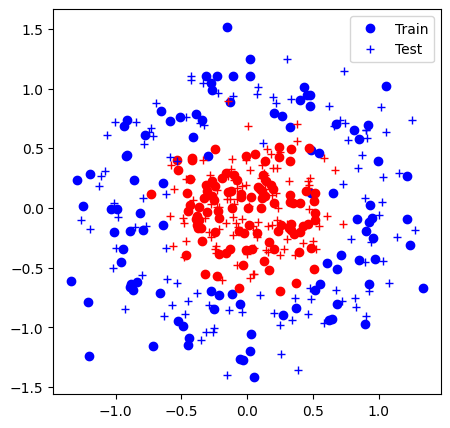

<Figure size 640x480 with 0 Axes>

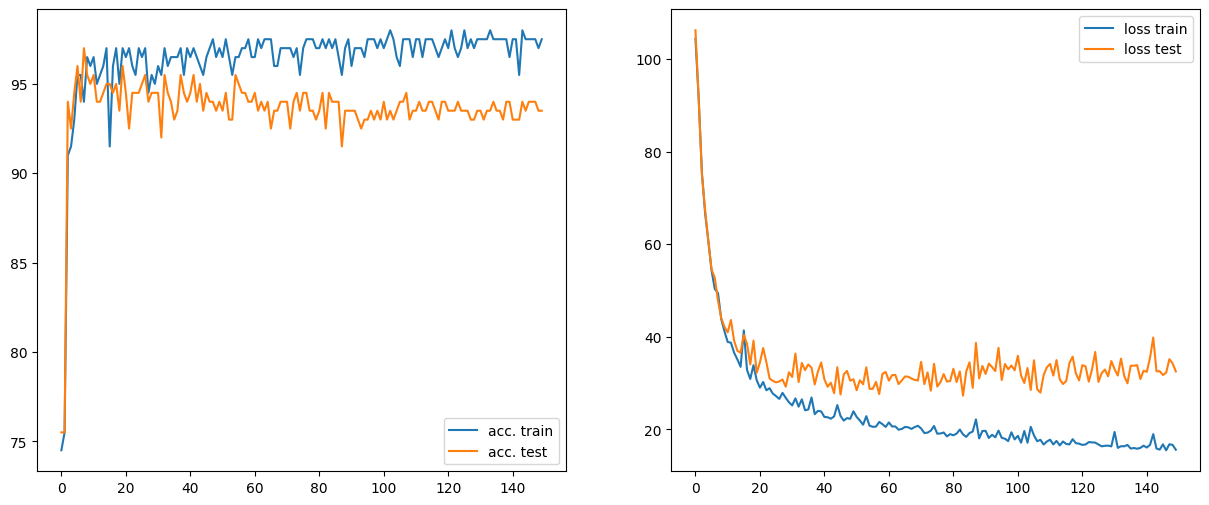

In [36]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
eta = 0.03

params = init_params(nx, nh, ny)

curves = [[],[], [], []]

# epoch
for iteration in range(150):

    # permute
    perm = np.random.permutation(N)
    Xtrain = data.Xtrain[perm, :]
    Ytrain = data.Ytrain[perm, :]

    # batches
    for j in range(N // Nbatch):

        indsBatch = range(j * Nbatch, (j+1) * Nbatch)
        X = Xtrain[indsBatch, :]
        Y = Ytrain[indsBatch, :]

        # write the optimization algorithm on the batch (X,Y)
        # using the functions: forward, loss_accuracy, sgd
        # and the backward function with autograd

        Yhat, outputs = forward(params, X)
        L, acc = loss_accuracy(Yhat, Y)
        L.backward()
        params = sgd(params, eta)



    Yhat_train, _ = forward(params, data.Xtrain)
    Yhat_test, _ = forward(params, data.Xtest)
    Ltrain, acctrain = loss_accuracy(Yhat_train, data.Ytrain)
    Ltest, acctest = loss_accuracy(Yhat_test, data.Ytest)
    # Ygrid, _ = forward(params, data.Xgrid)

    # title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
    # print(title)
    # # detach() is used to remove the predictions from the computational graph in autograd
    # data.plot_data_with_grid(Ygrid.detach(), title)

    curves[0].append(acctrain)
    curves[1].append(acctest)
    curves[2].append(Ltrain.detach().numpy())
    curves[3].append(Ltest.detach().numpy())

# fig = plt.figure()
# plt.plot(curves[0], label="acc. train")
# plt.plot(curves[1], label="acc. test")
# plt.plot(curves[2], label="loss train")
# plt.plot(curves[3], label="loss test")
# plt.legend()
# plt.show()

fig = plt.figure()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)

plt.plot(curves[0], label="acc. train")
plt.plot(curves[1], label="acc. test")
plt.legend()
plt.subplot(1,2,2)
plt.plot(curves[2], label="loss train")
plt.plot(curves[3], label="loss test")
plt.legend()

plt.show()

## Influence of learning rate

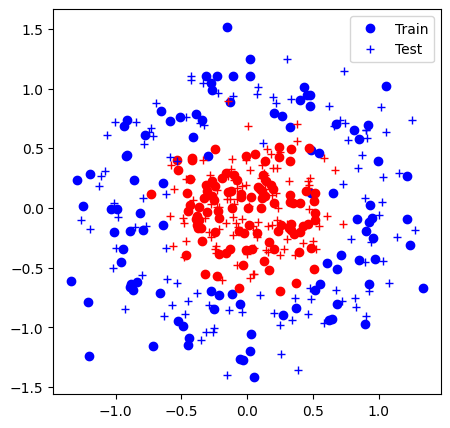

<Figure size 640x480 with 0 Axes>

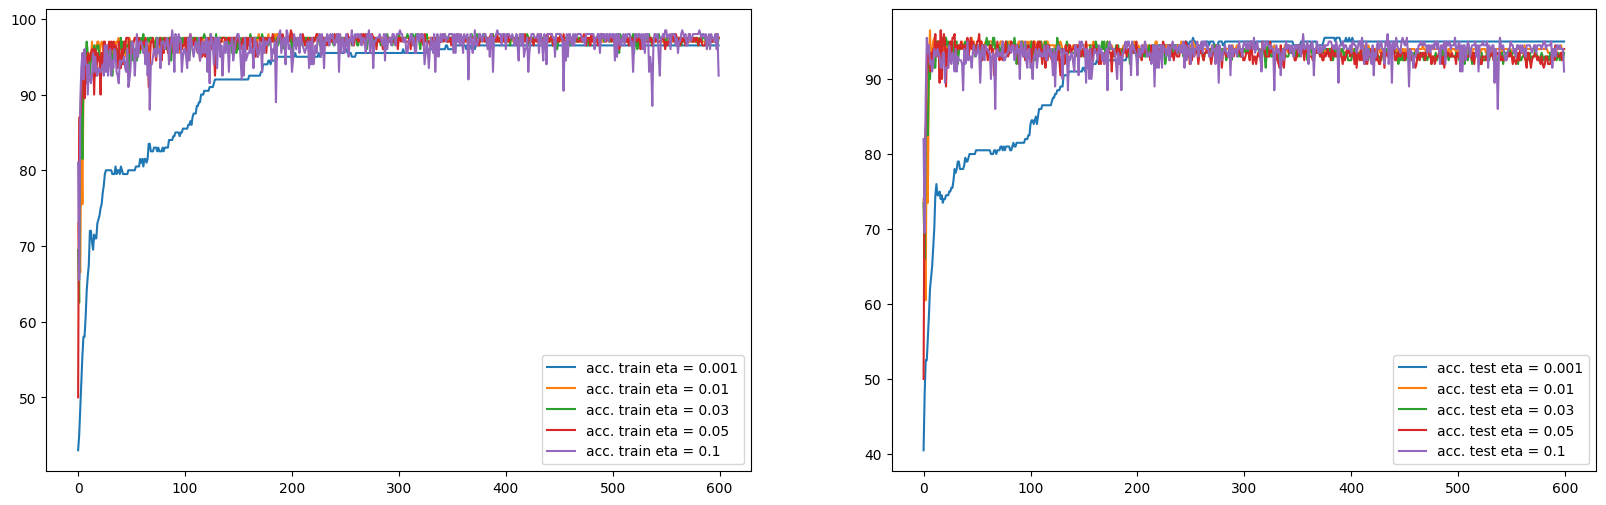

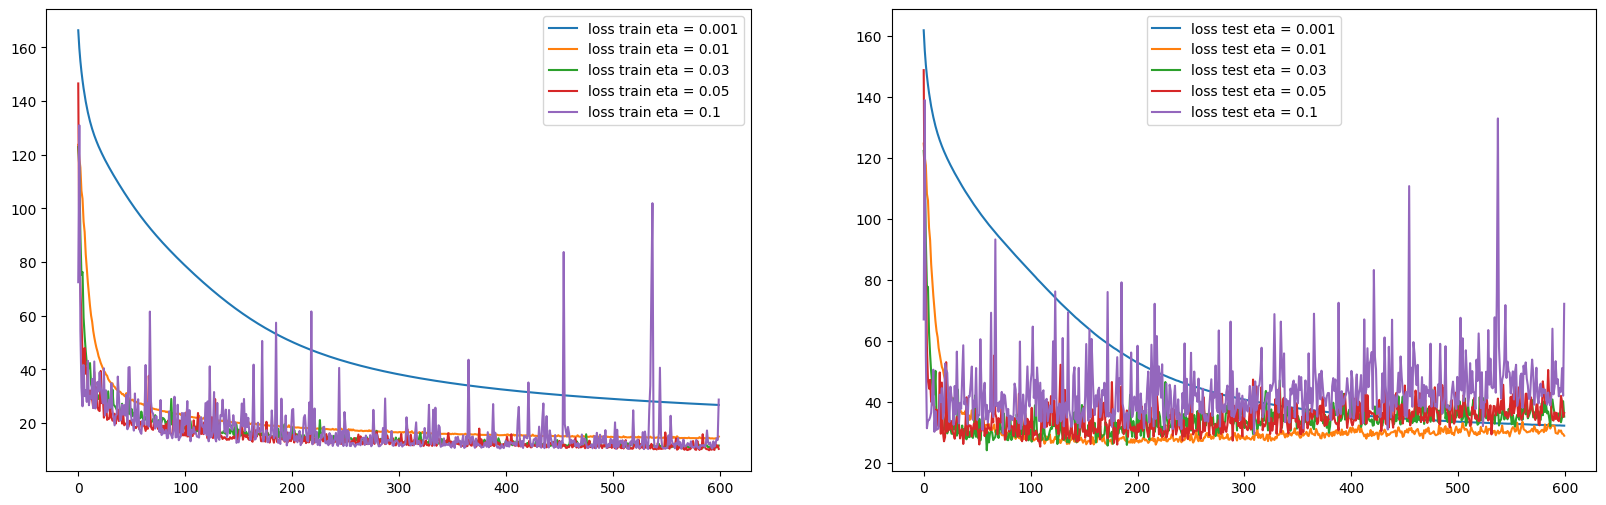

In [40]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_eta = [0.001,0.01,0.03,0.05,0.1]

params = init_params(nx, nh, ny)

curves = {eta: [[], [], [], []] for eta in l_eta}

for eta in l_eta:
    params = init_params(nx, nh, ny)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat, outputs = forward(params, X)
            L, acc = loss_accuracy(Yhat, Y)
            L.backward()
            params = sgd(params, eta)




        Yhat_train, _ = forward(params, data.Xtrain)
        Yhat_test, _ = forward(params, data.Xtest)
        Ltrain, acctrain = loss_accuracy(Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[eta][0].append(acctrain)
        curves[eta][1].append(acctest)
        curves[eta][2].append(Ltrain.detach().numpy())
        curves[eta][3].append(Ltest.detach().numpy())

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][0], label="acc. train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][1], label="acc. test eta = {}".format(eta))
plt.legend()

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][2], label="loss train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][3], label="loss test eta = {}".format(eta))
plt.legend()

plt.show()




## Influence of batch size

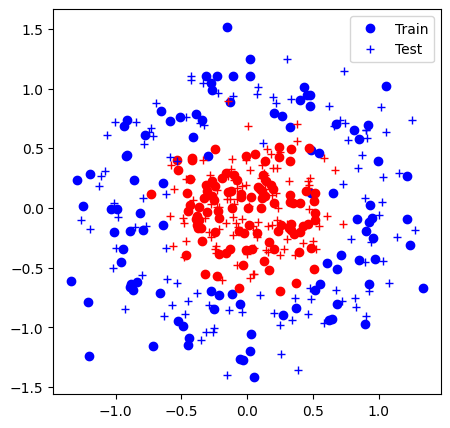

<Figure size 640x480 with 0 Axes>

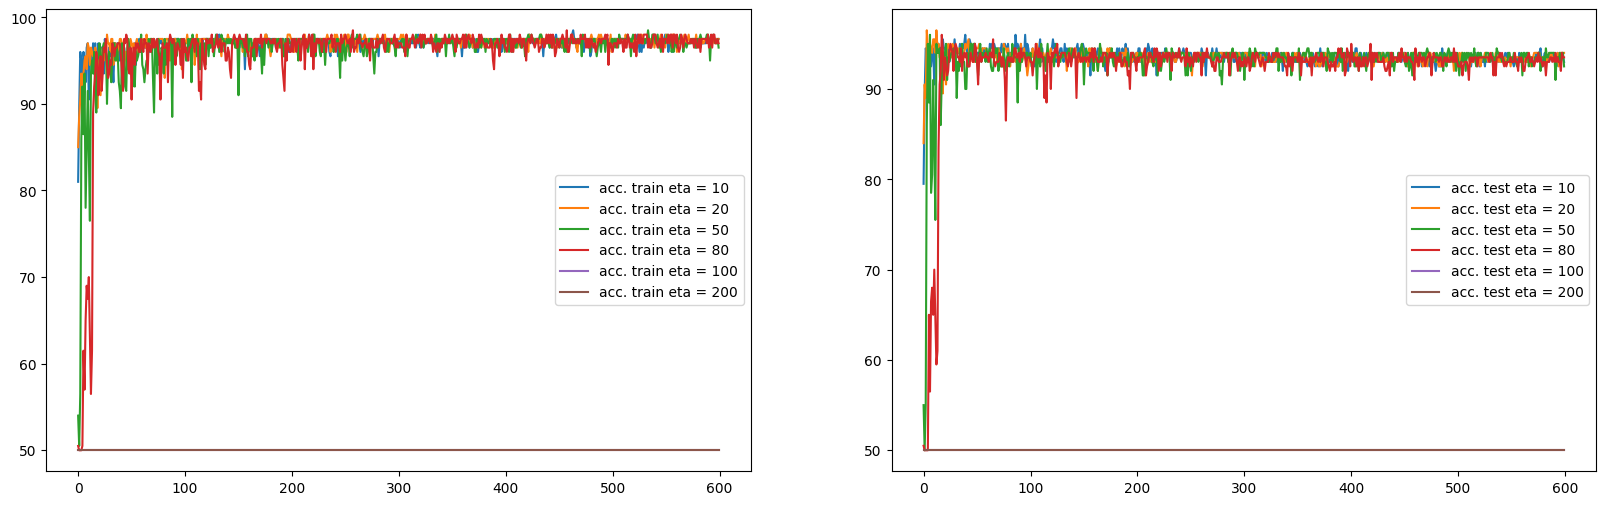

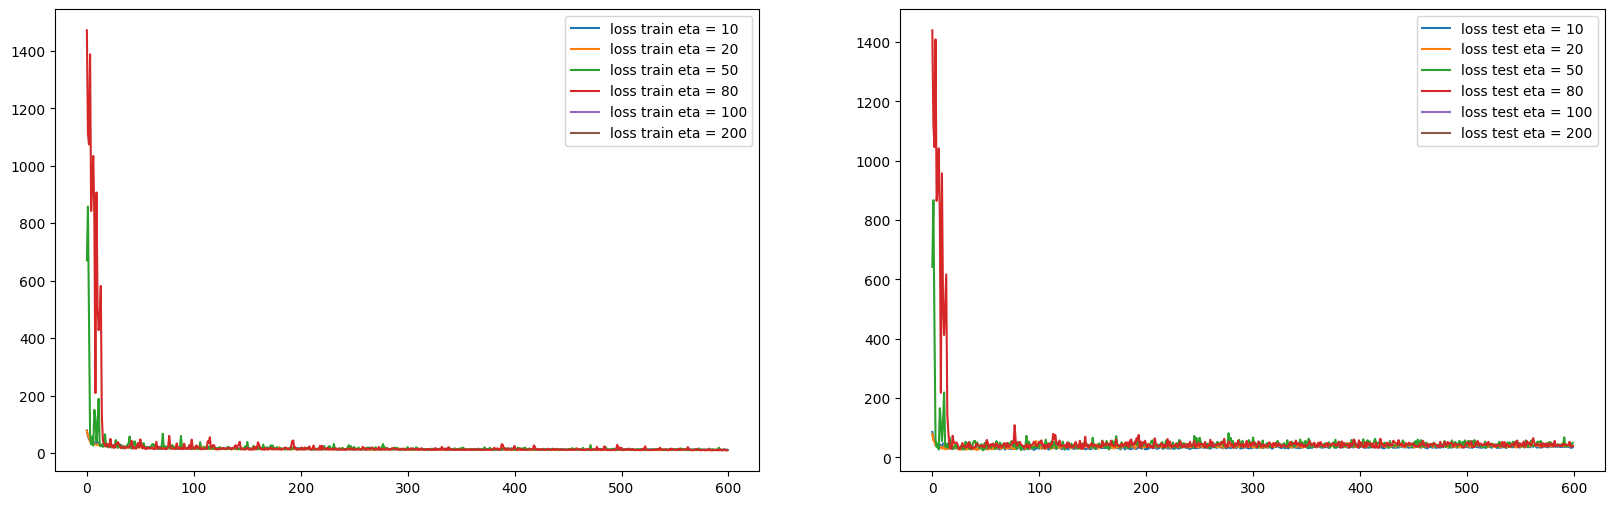

In [81]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
eta = 0.03
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_batch = [10, 20, 50, 80, 100,200]


curves = {Nbatch: [[], [], [], []] for Nbatch in l_batch}

for Nbatch in l_batch:
    params = init_params(nx, Nbatch, ny)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat, outputs = forward(params, X)
            L, acc = loss_accuracy(Yhat, Y)
            L.backward()
            params = sgd(params, eta)



        Yhat_train, _ = forward(params, data.Xtrain)
        Yhat_test, _ = forward(params, data.Xtest)
        Ltrain, acctrain = loss_accuracy(Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[Nbatch][0].append(acctrain)
        curves[Nbatch][1].append(acctest)
        curves[Nbatch][2].append(Ltrain.detach())
        curves[Nbatch][3].append(Ltest.detach())

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
    plt.plot(curves[Nbatch][0], label="acc. train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
    plt.plot(curves[Nbatch][1], label="acc. test eta = {}".format(Nbatch))
plt.legend()

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
    plt.plot(curves[Nbatch][2], label="loss train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
    plt.plot(curves[Nbatch][3], label="loss test eta = {}".format(Nbatch))
plt.legend()

plt.show()




# Part 3 : Simplification of the forward pass with `torch.nn`

`init_params` and `forward` are replaced by the `init_model` function which defines the network architecture and the loss.

In [54]:
def init_model(nx, nh, ny):

    model = torch.nn.Sequential(
    torch.nn.Linear(nx, nh),
    torch.nn.Tanh(),
    torch.nn.Linear(nh, ny),
    )
    loss = torch.nn.CrossEntropyLoss()

    return model, loss

In [105]:
def loss_accuracy(loss, Yhat, Y):
    L = loss(Yhat,Y)
    acc = (torch.sum(torch.argmax(Yhat, 1) == torch.argmax(Y, 1)).float() / Y.size(0)) * 100 # in percentage

    return L, acc

# def loss_accuracy(loss, Yhat, Y):
#     L = loss(Yhat, Y)
#     acc = 100 * torch.mean((Yhat.argmax(1) == Y.argmax(1)).float())
#     return L, acc

In [106]:
def sgd(model, eta):

    with torch.no_grad():
        for param in model.parameters():
            param -= eta * param.grad
            param.grad.zero_()
    
    return model


## Global learning procedure with autograd and `torch.nn`

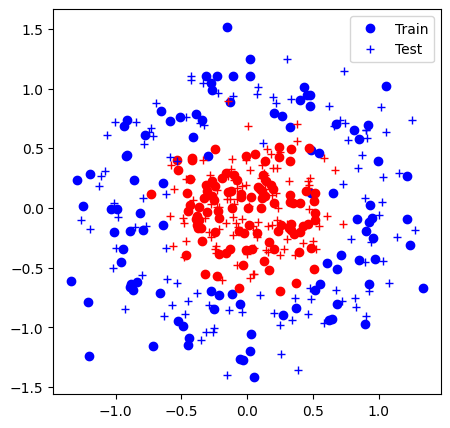

<Figure size 640x480 with 0 Axes>

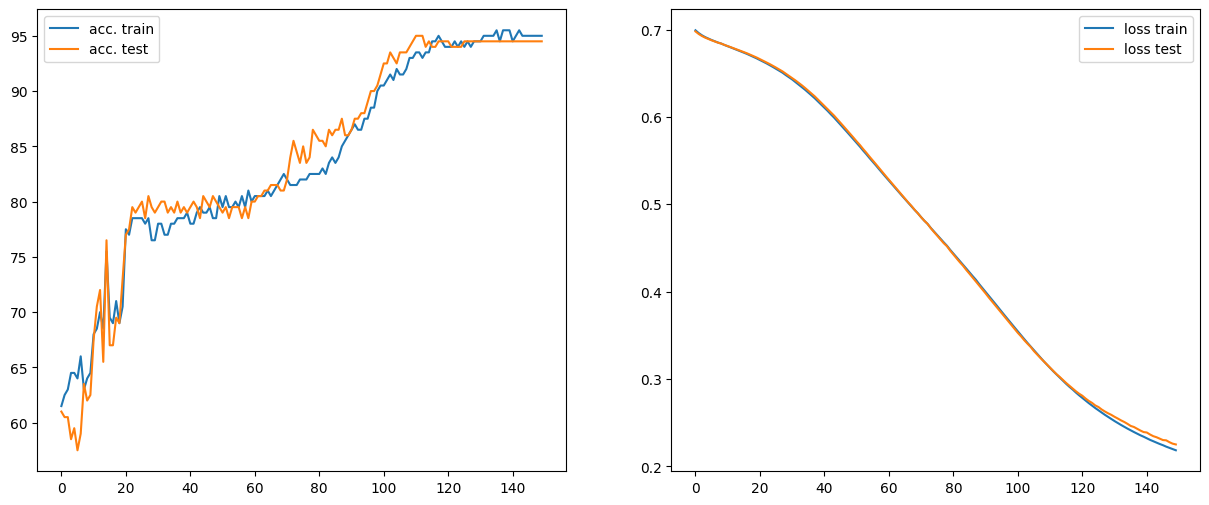

In [57]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
eta = 0.03

model, loss = init_model(nx, nh, ny)

curves = [[],[], [], []]

# epoch
for iteration in range(150):

    # permute
    perm = np.random.permutation(N)
    Xtrain = data.Xtrain[perm, :]
    Ytrain = data.Ytrain[perm, :]


    # batches
    for j in range(N // Nbatch):

        indsBatch = range(j * Nbatch, (j+1) * Nbatch)
        X = Xtrain[indsBatch, :]
        Y = Ytrain[indsBatch, :]

        # write the optimization algorithm on the batch (X,Y)
        # using the functions: loss_accuracy, sgd
        # the forward with the predict method from the model
        # and the backward function with autograd

        Yhat = model(X)
        L, acc = loss_accuracy(loss,Yhat, Y)
        L.backward()
        model = sgd(model, eta)


    Yhat_train = model(data.Xtrain)
    Yhat_test = model(data.Xtest)
    Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
    Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)
    # Ygrid = model(data.Xgrid)

    # title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
    # print(title)
    # data.plot_data_with_grid(torch.nn.Softmax(dim=1)(Ygrid.detach()), title)

    curves[0].append(acctrain)
    curves[1].append(acctest)
    curves[2].append(Ltrain.detach().numpy())
    curves[3].append(Ltest.detach().numpy())

# fig = plt.figure()
# plt.plot(curves[0], label="acc. train")
# plt.plot(curves[1], label="acc. test")
# plt.plot(curves[2], label="loss train")
# plt.plot(curves[3], label="loss test")
# plt.legend()
# plt.show()

fig = plt.figure()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)

plt.plot(curves[0], label="acc. train")
plt.plot(curves[1], label="acc. test")
plt.legend()
plt.subplot(1,2,2)
plt.plot(curves[2], label="loss train")
plt.plot(curves[3], label="loss test")
plt.legend()

plt.show()

## Influence of learning rate

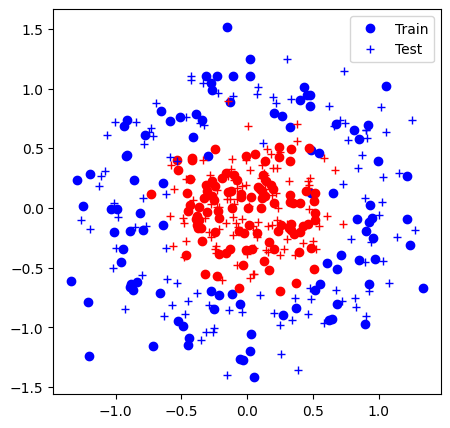

<Figure size 640x480 with 0 Axes>

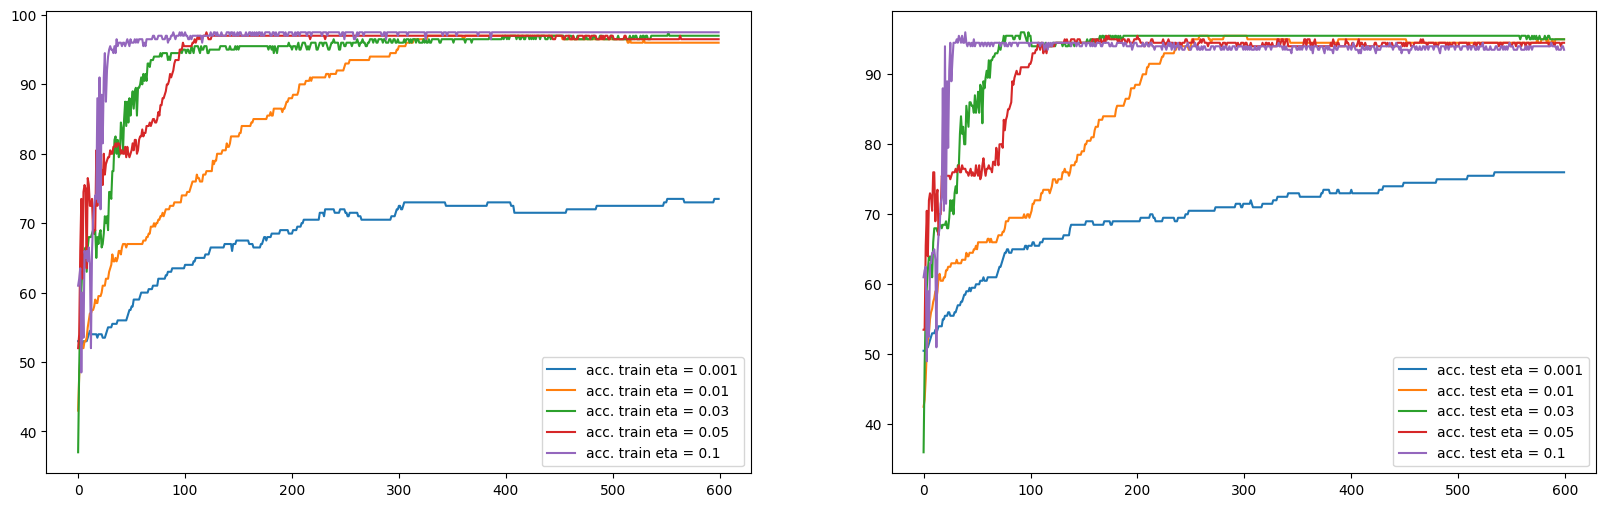

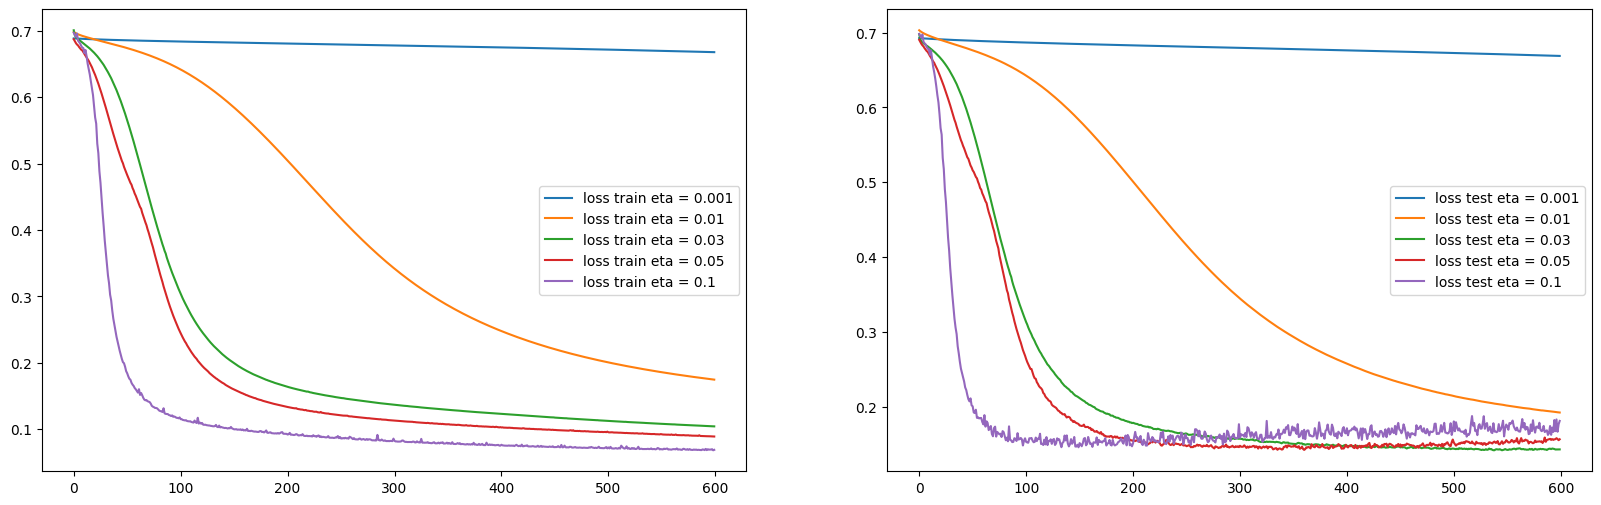

In [61]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_eta = [0.001,0.01,0.03,0.05,0.1]

model, loss = init_model(nx, nh, ny)

curves = {eta: [[], [], [], []] for eta in l_eta}

for eta in l_eta:
    model,loss = init_model(nx, nh, ny)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat = model(X)
            L, acc = loss_accuracy(loss,Yhat, Y)
            L.backward()
            model = sgd(model, eta)


        Yhat_train = model(data.Xtrain)
        Yhat_test = model(data.Xtest)
        Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[eta][0].append(acctrain)
        curves[eta][1].append(acctest)
        curves[eta][2].append(Ltrain.detach())
        curves[eta][3].append(Ltest.detach())

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][0], label="acc. train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][1], label="acc. test eta = {}".format(eta))
plt.legend()

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][2], label="loss train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][3], label="loss test eta = {}".format(eta))
plt.legend()

plt.show()




## Influence of batch size

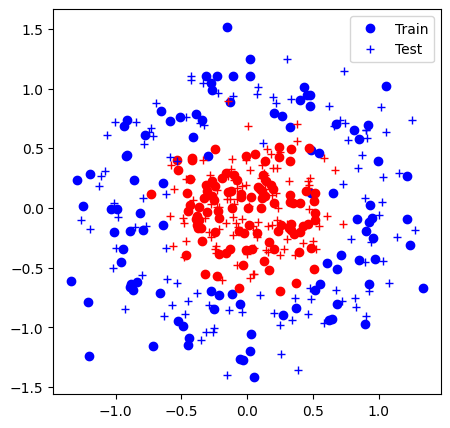

<Figure size 640x480 with 0 Axes>

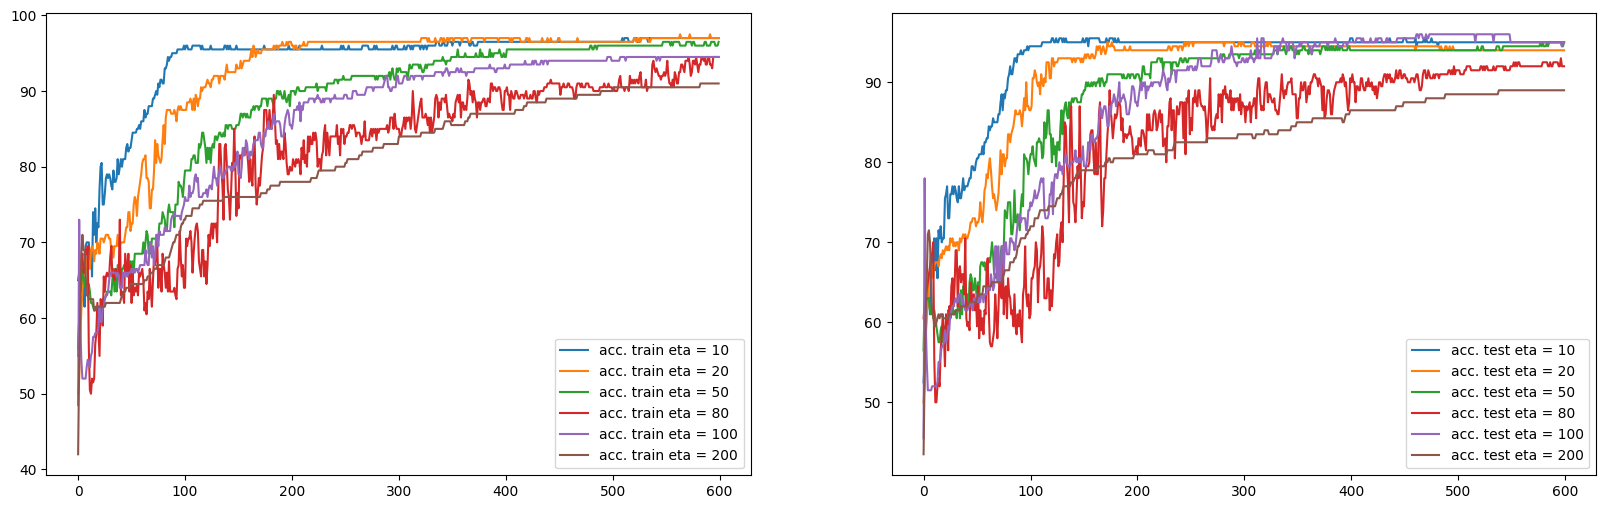

<Figure size 640x480 with 0 Axes>

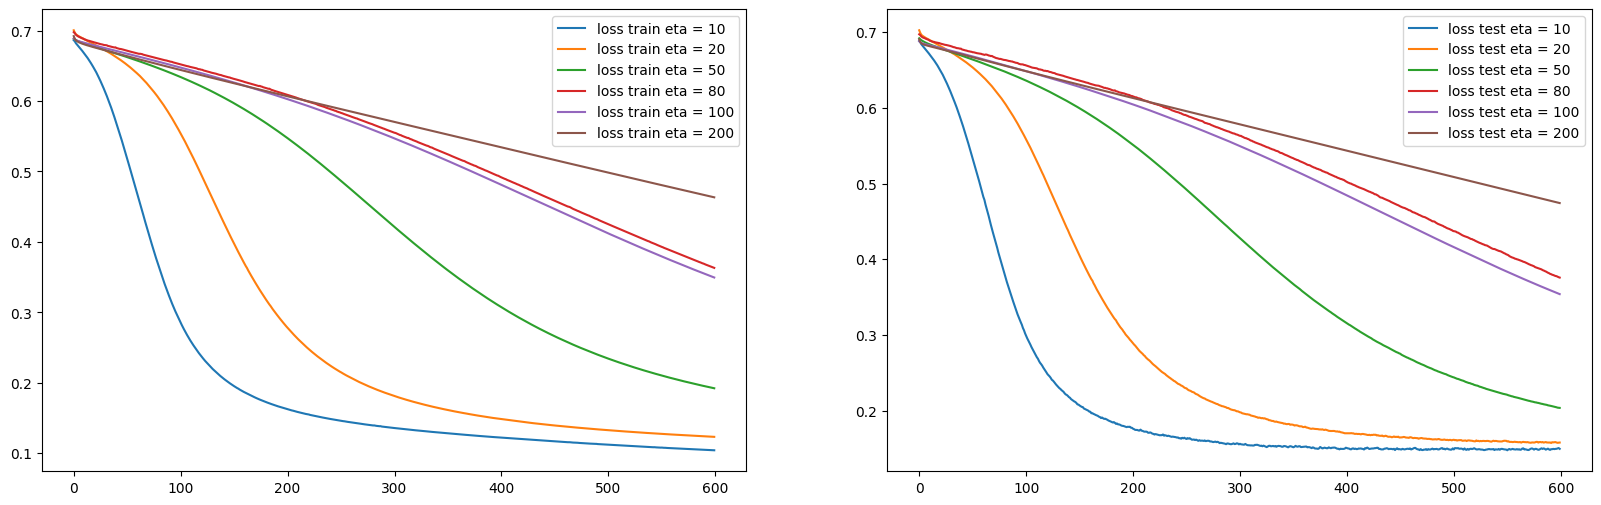

In [62]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
eta = 0.03
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_batch = [10, 20, 50, 80, 100,200]


curves = {Nbatch: [[], [], [], []] for Nbatch in l_batch}

for Nbatch in l_batch:
    model, loss = init_model(nx, Nbatch, ny)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat = model(X)
            L, acc = loss_accuracy(loss,Yhat, Y)
            L.backward()
            model = sgd(model, eta)




        Yhat_train = model(data.Xtrain)
        Yhat_test = model(data.Xtest)
        Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[Nbatch][0].append(acctrain)
        curves[Nbatch][1].append(acctest)
        curves[Nbatch][2].append(Ltrain.detach())
        curves[Nbatch][3].append(Ltest.detach())

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][0], label="acc. train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][1], label="acc. test eta = {}".format(Nbatch))
plt.legend()

fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][2], label="loss train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][3], label="loss test eta = {}".format(Nbatch))
plt.legend()

plt.show()




# Part 4 : Simplification of the SGD with `torch.optim`

In [104]:
def init_model(nx, nh, ny, eta):
    model = torch.nn.Sequential(
    torch.nn.Linear(nx, nh),
    torch.nn.Tanh(),
    torch.nn.Linear(nh, ny),
    )
    loss = torch.nn.CrossEntropyLoss()
    optim = torch.optim.SGD(model.parameters(),lr=eta)

    return model, loss, optim

The `sgd` function is replaced by calling the `optim.zero_grad()` before the backward and `optim.step()` after.

## Algorithme global d'apprentissage (avec autograd, les couches `torch.nn` et `torch.optim`)

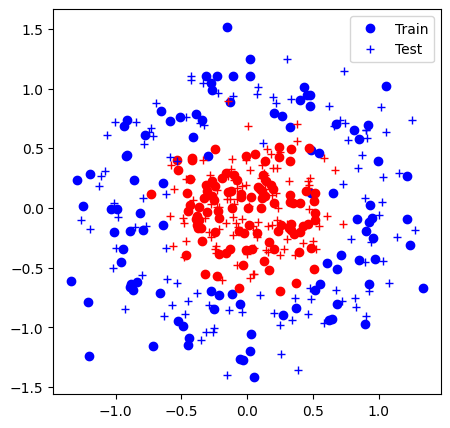

<Figure size 640x480 with 0 Axes>

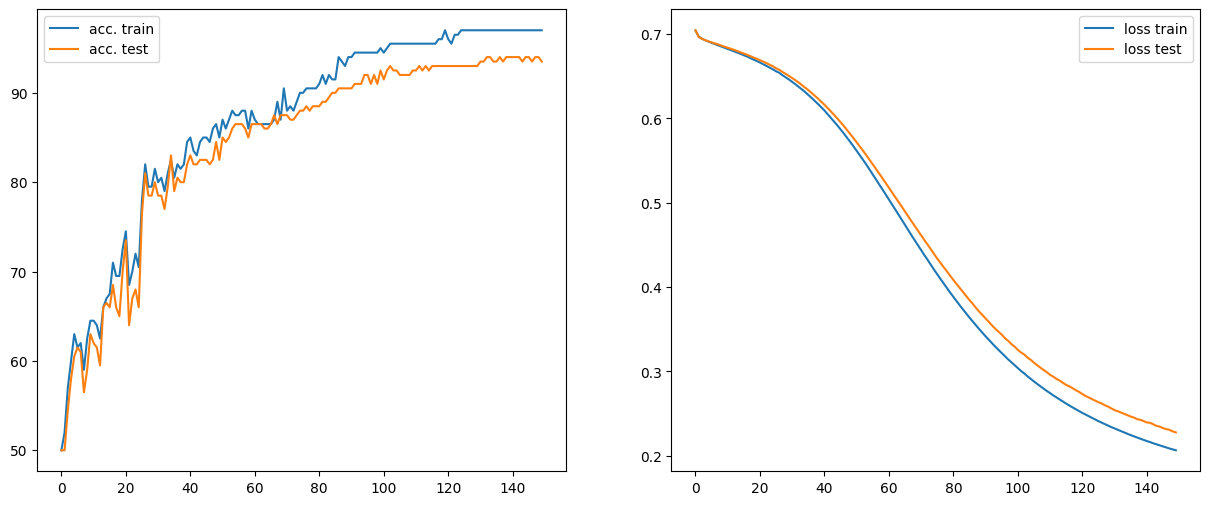

In [65]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
eta = 0.03

model, loss, optim = init_model(nx, nh, ny, eta)

curves = [[],[], [], []]

# epoch
for iteration in range(150):

    # permute
    perm = np.random.permutation(N)
    Xtrain = data.Xtrain[perm, :]
    Ytrain = data.Ytrain[perm, :]

    for j in range(N // Nbatch):

        indsBatch = range(j * Nbatch, (j+1) * Nbatch)
        X = Xtrain[indsBatch, :]
        Y = Ytrain[indsBatch, :]

        # write the optimization algorithm on the batch (X,Y)
        # using the functions: loss_accuracy
        # the forward with the predict method from the model
        # the backward function with autograd
        # and then an optimization step

        Yhat = model(X)
        L, acc = loss_accuracy(loss,Yhat, Y)
        optim.zero_grad()
        L.backward()
        optim.step()

    

    Yhat_train = model(data.Xtrain)
    Yhat_test = model(data.Xtest)
    Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
    Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)
    # Ygrid = model(data.Xgrid)

    # title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
    # print(title)
    # data.plot_data_with_grid(torch.nn.Softmax(dim=1)(Ygrid.detach()), title)

    curves[0].append(acctrain)
    curves[1].append(acctest)
    curves[2].append(Ltrain.detach())
    curves[3].append(Ltest.detach())

# fig = plt.figure()
# plt.plot(curves[0], label="acc. train")
# plt.plot(curves[1], label="acc. test")
# plt.plot(curves[2], label="loss train")
# plt.plot(curves[3], label="loss test")
# plt.legend()
# plt.show()

fig = plt.figure()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)

plt.plot(curves[0], label="acc. train")
plt.plot(curves[1], label="acc. test")
plt.legend()
plt.subplot(1,2,2)
plt.plot(curves[2], label="loss train")
plt.plot(curves[3], label="loss test")
plt.legend()

plt.show()

## Influence of learning rate

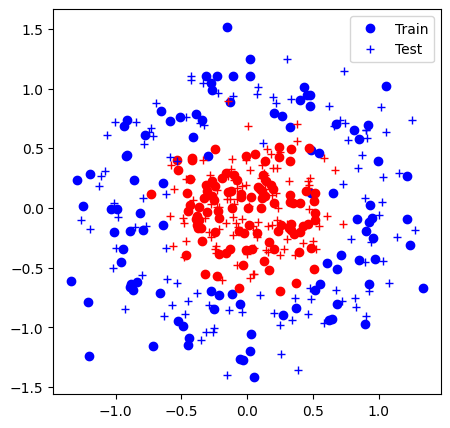

<Figure size 640x480 with 0 Axes>

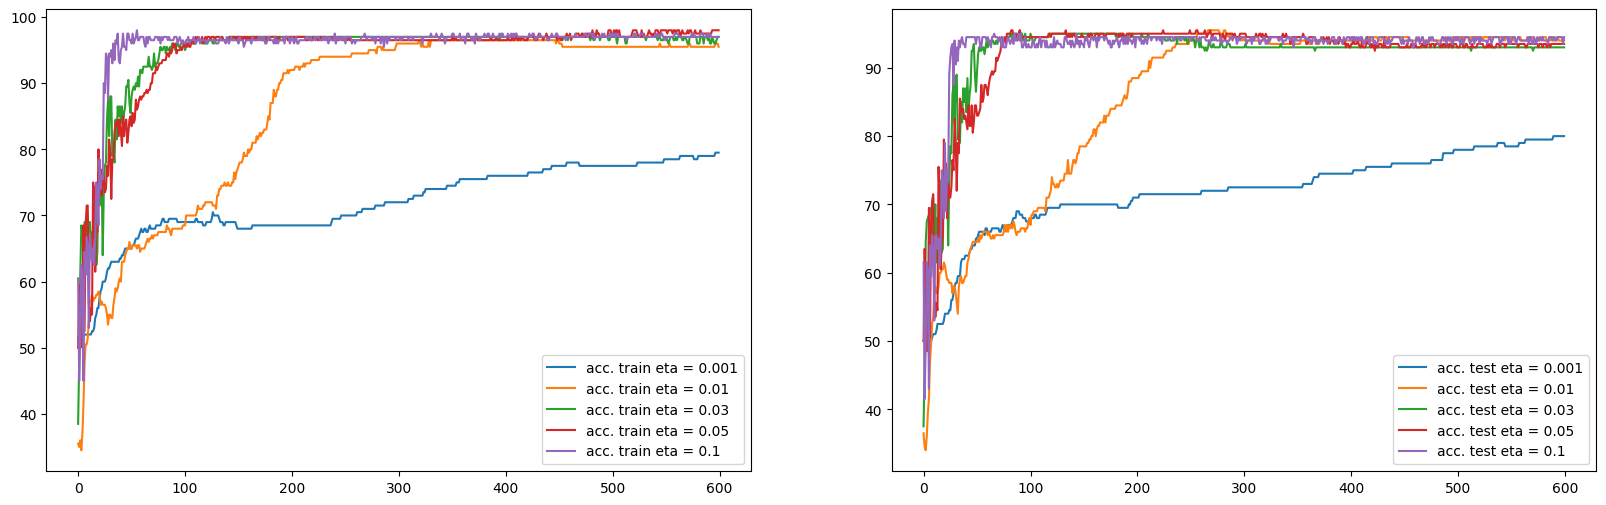

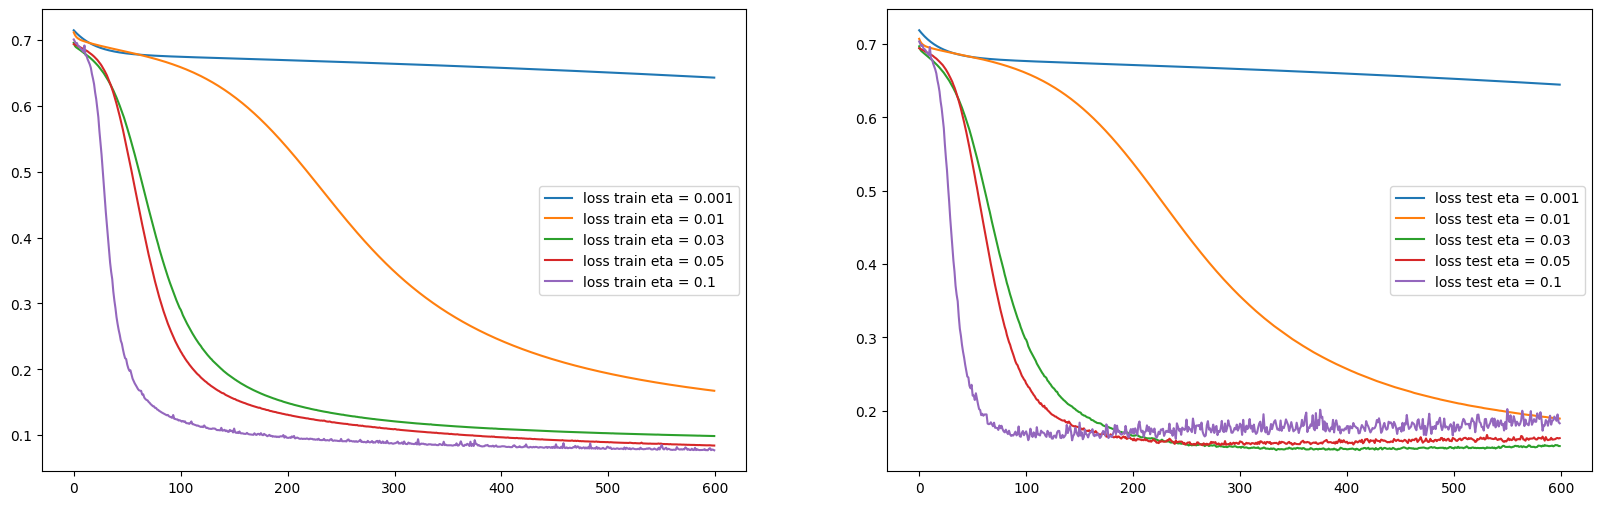

In [67]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
Nbatch = 10
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_eta = [0.001,0.01,0.03,0.05,0.1]


curves = {eta: [[], [], [], []] for eta in l_eta}

for eta in l_eta:
    
    model,loss, optim = init_model(nx, nh, ny, eta)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat = model(X)
            L, acc = loss_accuracy(loss,Yhat, Y)
            optim.zero_grad()
            L.backward()
            optim.step()




        Yhat_train = model(data.Xtrain)
        Yhat_test = model(data.Xtest)
        Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[eta][0].append(acctrain)
        curves[eta][1].append(acctest)
        curves[eta][2].append(Ltrain.detach())
        curves[eta][3].append(Ltest.detach())

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][0], label="acc. train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][1], label="acc. test eta = {}".format(eta))
plt.legend()

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for eta in l_eta:
    plt.plot(curves[eta][2], label="loss train eta = {}".format(eta))
plt.legend()
plt.subplot(1,2,2)
for eta in l_eta:
    plt.plot(curves[eta][3], label="loss test eta = {}".format(eta))
plt.legend()

plt.show()




## Influence of batch size

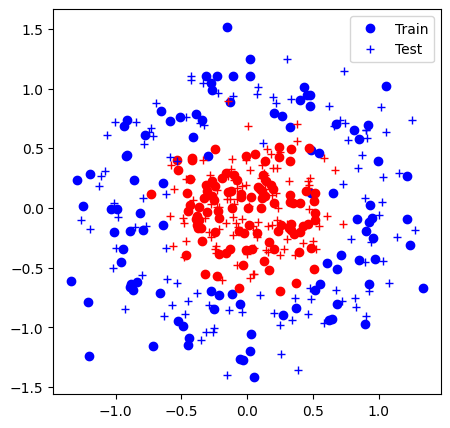

<Figure size 640x480 with 0 Axes>

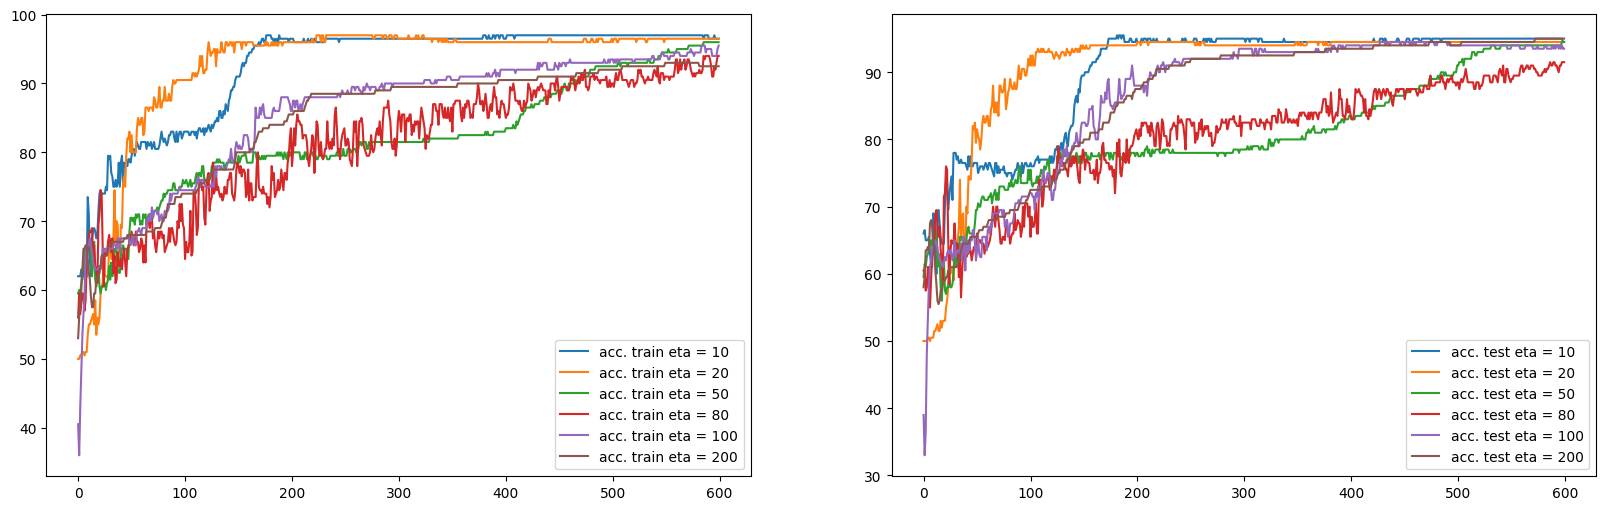

<Figure size 640x480 with 0 Axes>

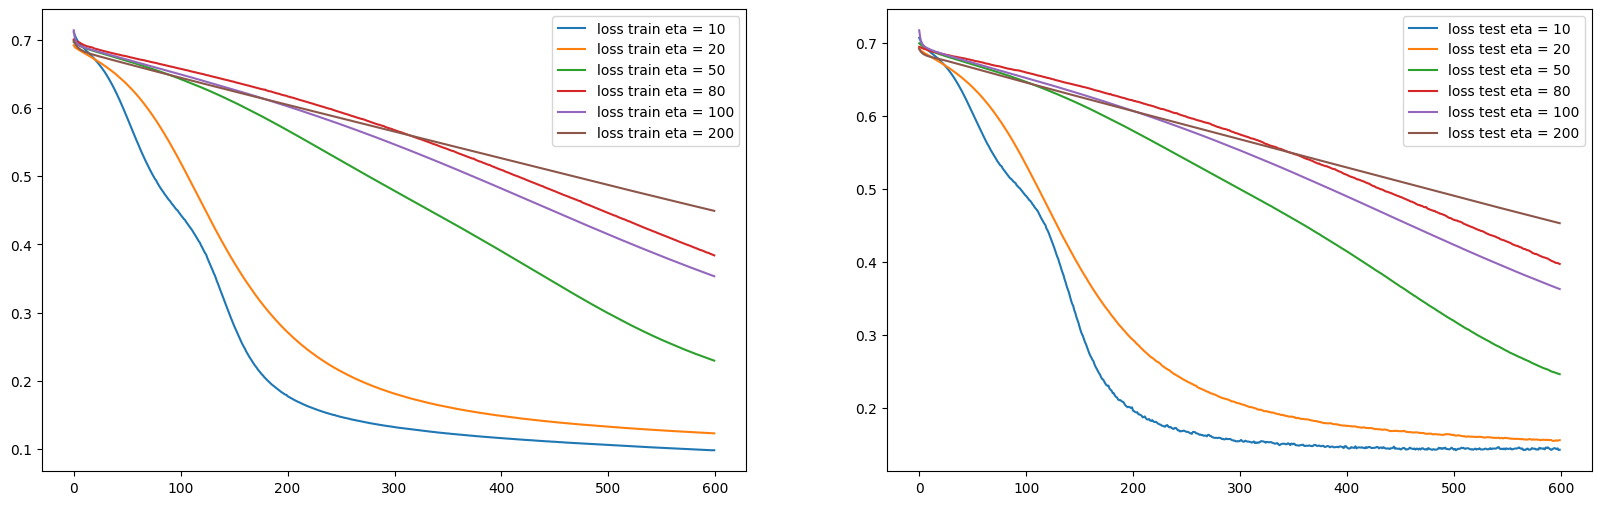

In [68]:
# init
data = CirclesData()
data.plot_data()
N = data.Xtrain.shape[0]
eta = 0.03
nx = data.Xtrain.shape[1]
nh = 10
ny = data.Ytrain.shape[1]
l_batch = [10, 20, 50, 80, 100,200]


curves = {Nbatch: [[], [], [], []] for Nbatch in l_batch}

for Nbatch in l_batch:
    model, loss, optim = init_model(nx, Nbatch, ny, eta)

    # epoch
    for iteration in range(600):

        # permute
        perm = np.random.permutation(N)
        Xtrain = data.Xtrain[perm, :]
        Ytrain = data.Ytrain[perm, :]

        # batches
        for j in range(N // Nbatch):

            indsBatch = range(j * Nbatch, (j+1) * Nbatch)
            X = Xtrain[indsBatch, :]
            Y = Ytrain[indsBatch, :]

            # write the optimization algorithm on the batch (X,Y)
            # using the functions: forward, loss_accuracy, backward, sgd

            Yhat = model(X)
            L, acc = loss_accuracy(loss,Yhat, Y)
            optim.zero_grad()
            L.backward()
            optim.step()




        Yhat_train = model(data.Xtrain)
        Yhat_test = model(data.Xtest)
        Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
        Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)
        #Ygrid, _ = forward(params, data.Xgrid)

        #title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
        #print(title)
        #data.plot_data_with_grid(Ygrid, title)

        curves[Nbatch][0].append(acctrain)
        curves[Nbatch][1].append(acctest)
        curves[Nbatch][2].append(Ltrain.detach())
        curves[Nbatch][3].append(Ltest.detach())

# split the plots of train_acc and train_loss and  test_acc and test_loss (total 4 plots)
fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][0], label="acc. train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][1], label="acc. test eta = {}".format(Nbatch))
plt.legend()

fig = plt.figure()
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][2], label="loss train eta = {}".format(Nbatch))
plt.legend()
plt.subplot(1,2,2)
for Nbatch in l_batch:
        plt.plot(curves[Nbatch][3], label="loss test eta = {}".format(Nbatch))
plt.legend()

plt.show()



# Part 5 : MNIST

Apply the code from previous part code to the MNIST dataset.

In [117]:
# init
data = MNISTData()
N = data.Xtrain.shape[0]
Nbatch = 100
nx = data.Xtrain.shape[1]
nh = 100
ny = data.Ytrain.shape[1]
eta = 0.03

Iter 0: Acc train 84.9% (0.53), acc test 85.4% (0.50)
Iter 1: Acc train 86.9% (0.45), acc test 87.4% (0.43)
Iter 2: Acc train 86.6% (0.46), acc test 87.0% (0.45)
Iter 3: Acc train 88.1% (0.40), acc test 88.3% (0.40)
Iter 4: Acc train 88.5% (0.40), acc test 88.7% (0.39)
Iter 5: Acc train 88.8% (0.39), acc test 89.3% (0.37)
Iter 6: Acc train 88.3% (0.39), acc test 88.9% (0.38)
Iter 7: Acc train 87.5% (0.41), acc test 88.2% (0.40)
Iter 8: Acc train 88.9% (0.37), acc test 89.3% (0.36)
Iter 9: Acc train 89.4% (0.36), acc test 89.3% (0.35)
Iter 10: Acc train 87.3% (0.41), acc test 87.1% (0.41)
Iter 11: Acc train 87.9% (0.40), acc test 88.1% (0.40)
Iter 12: Acc train 88.1% (0.40), acc test 88.6% (0.39)
Iter 13: Acc train 88.4% (0.38), acc test 88.6% (0.38)
Iter 14: Acc train 87.8% (0.40), acc test 87.8% (0.39)
Iter 15: Acc train 88.5% (0.39), acc test 88.1% (0.39)
Iter 16: Acc train 89.1% (0.36), acc test 89.7% (0.35)
Iter 17: Acc train 89.5% (0.34), acc test 89.6% (0.34)
Iter 18: Acc train 8

<Figure size 640x480 with 0 Axes>

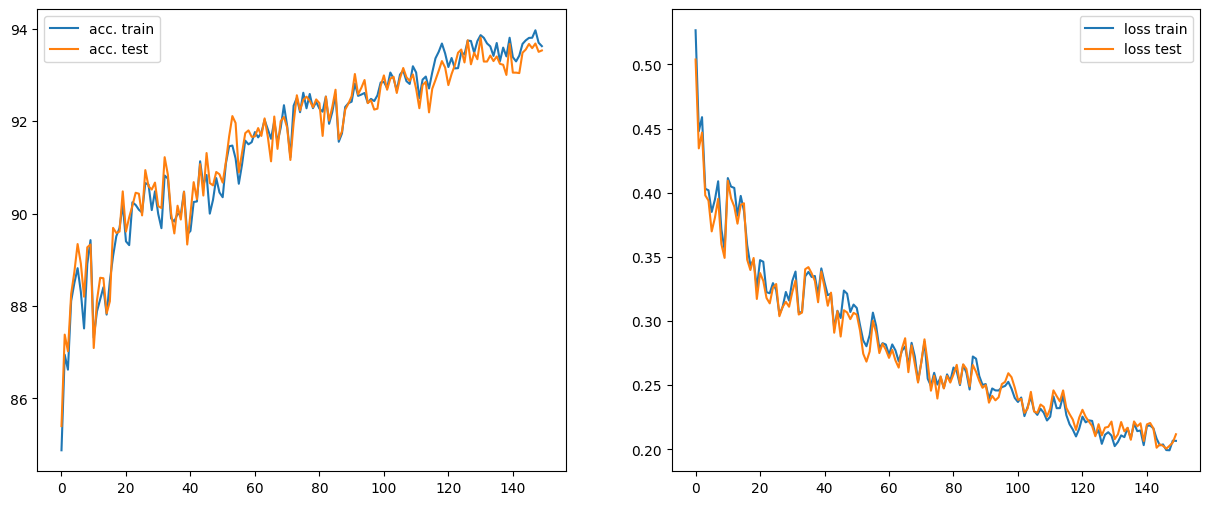

In [107]:
model, loss, optim = init_model(nx, nh, ny, eta)

curves = [[],[], [], []]

# epoch
for iteration in range(150):

    # permute
    perm = np.random.permutation(N)
    Xtrain = data.Xtrain[perm, :]
    Ytrain = data.Ytrain[perm, :]

    for j in range(N // Nbatch):

        indsBatch = range(j * Nbatch, (j+1) * Nbatch)
        X = Xtrain[indsBatch, :]
        Y = Ytrain[indsBatch, :]

        Yhat = model(X)
        L, acc = loss_accuracy(loss,Yhat, Y)
        optim.zero_grad()
        L.backward()
        optim.step()

    

    Yhat_train = model(data.Xtrain)
    Yhat_test = model(data.Xtest)
    Ltrain, acctrain = loss_accuracy(loss, Yhat_train, data.Ytrain)
    Ltest, acctest = loss_accuracy(loss, Yhat_test, data.Ytest)

    title = 'Iter {}: Acc train {:.1f}% ({:.2f}), acc test {:.1f}% ({:.2f})'.format(iteration, acctrain, Ltrain, acctest, Ltest)
    print(title)
    # data.plot_data_with_grid(torch.nn.Softmax(dim=1)(Ygrid.detach()), title)

    curves[0].append(acctrain)
    curves[1].append(acctest)
    curves[2].append(Ltrain.detach())
    curves[3].append(Ltest.detach())

# fig = plt.figure()
# plt.plot(curves[0], label="acc. train")
# plt.plot(curves[1], label="acc. test")
# plt.plot(curves[2], label="loss train")
# plt.plot(curves[3], label="loss test")
# plt.legend()
# plt.show()

fig = plt.figure()
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)

plt.plot(curves[0], label="acc. train")
plt.plot(curves[1], label="acc. test")
plt.legend()
plt.subplot(1,2,2)
plt.plot(curves[2], label="loss train")
plt.plot(curves[3], label="loss test")
plt.legend()

plt.show()

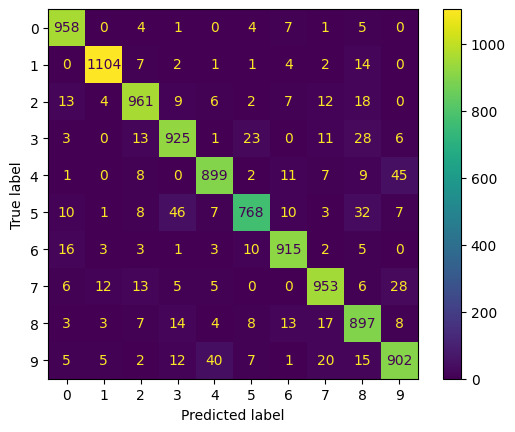

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(data.Ytest.argmax(dim=1), Yhat_test.detach().argmax(dim=1))

cm_display = ConfusionMatrixDisplay(cm).plot()


<Figure size 640x480 with 0 Axes>

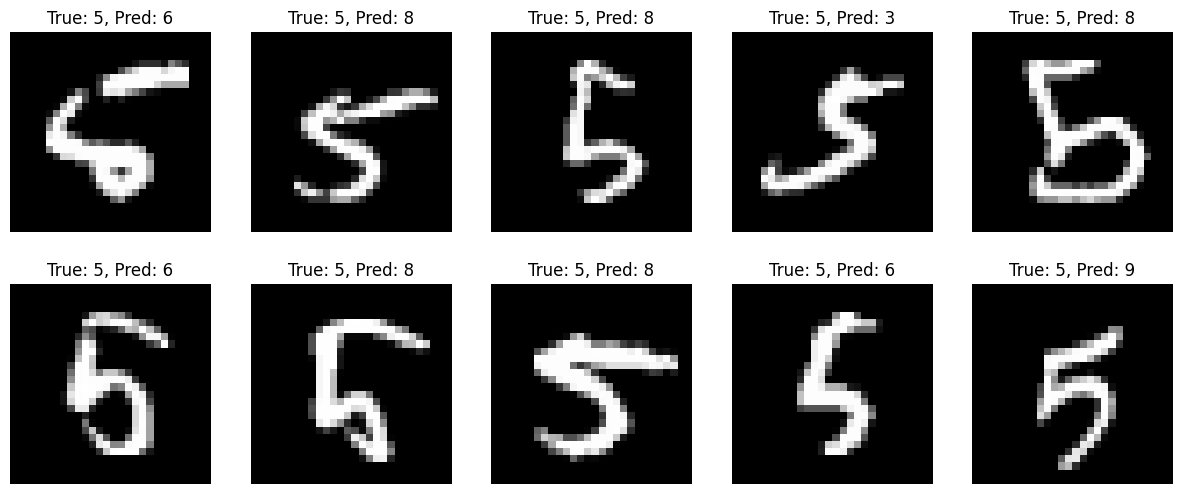

<Figure size 640x480 with 0 Axes>

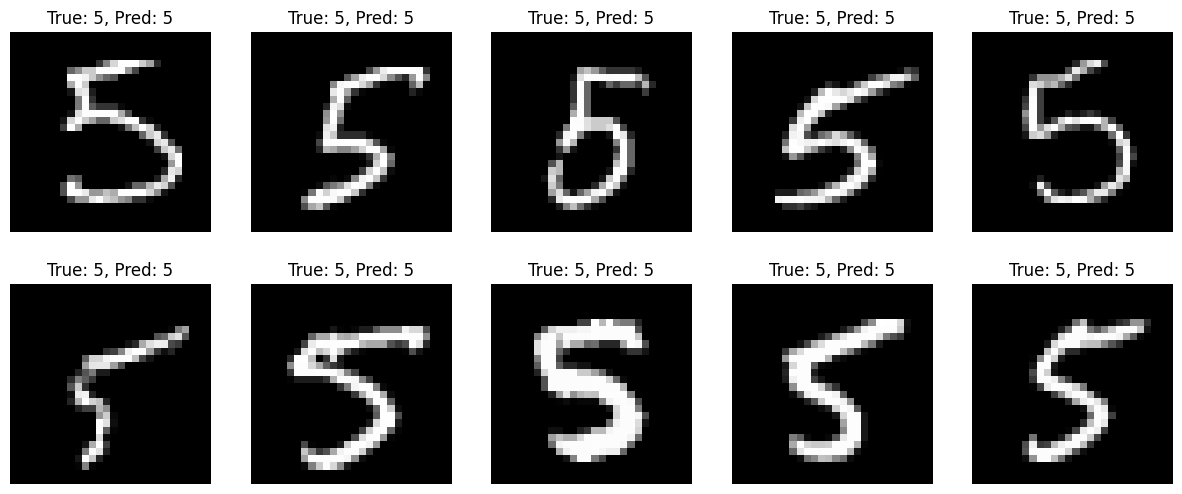

In [122]:
# choisr des exemples bien classés et mal classés

# choisir des exemples mal classés avec class 5
inds = (data.Ytest.argmax(dim=1) == 5) & (Yhat_test.detach().argmax(dim=1) != 5)
inds = np.where(inds == True)[0]

# Afficher les exemples
# exemple of misclassified images
fig = plt.figure()
plt.figure(figsize=(15,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(data.Xtest[inds[i],:].reshape(28,28), cmap='gray')  # Fix the reshape dimensions
    plt.title('True: {}, Pred: {}'.format(data.Ytest[inds[i]].argmax(), Yhat_test[inds[i]].argmax()))
    plt.axis('off')

# choisir des exemples bien classés with class 5
inds = (data.Ytest.argmax(dim=1) == 5) & (Yhat_test.detach().argmax(dim=1) == 5)
inds = np.where(inds == True)[0]

# Afficher les exemples
fig = plt.figure()
plt.figure(figsize=(15,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(data.Xtest[inds[i],:].reshape(28,28), cmap='gray')  # Fix the reshape dimensions
    plt.title('True: {}, Pred: {}'.format(data.Ytest[inds[i]].argmax(), Yhat_test[inds[i]].argmax()))
    plt.axis('off')



# Part 6: Bonus: SVM


Train a SVM model on the Circles dataset.

Ideas :
- First try a linear SVM (sklearn.svm.LinearSVC dans scikit-learn). Does it work well ? Why ?
- Then try more complex kernels (sklearn.svm.SVC). Which one is the best ? why ?
- Does the parameter C of regularization have an impact? Why ?

In [112]:
# data
data = CirclesData()
Xtrain = data.Xtrain.numpy()
Ytrain = data.Ytrain[:, 0].numpy()

Xgrid = data.Xgrid.numpy()

Xtest = data.Xtest.numpy()
Ytest = data.Ytest[:, 0].numpy()

def plot_svm_predictions(data, predictions):
      plt.figure(2)
      plt.clf()
      plt.imshow(np.reshape(predictions, (40,40)))
      plt.plot(data._Xtrain[data._Ytrain[:,0] == 1,0]*10+20, data._Xtrain[data._Ytrain[:,0] == 1,1]*10+20, 'bo', label="Train")
      plt.plot(data._Xtrain[data._Ytrain[:,1] == 1,0]*10+20, data._Xtrain[data._Ytrain[:,1] == 1,1]*10+20, 'ro')
      plt.plot(data._Xtest[data._Ytest[:,0] == 1,0]*10+20, data._Xtest[data._Ytest[:,0] == 1,1]*10+20, 'b+', label="Test")
      plt.plot(data._Xtest[data._Ytest[:,1] == 1,0]*10+20, data._Xtest[data._Ytest[:,1] == 1,1]*10+20, 'r+')
      plt.xlim(0,39)
      plt.ylim(0,39)
      plt.clim(0.3,0.7)
      plt.draw()
      plt.pause(1e-3)

In [113]:
import sklearn.svm

############################
### Your code here   #######
### Train the SVM    #######
## See https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
## and https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
############################

svm = sklearn.svm.LinearSVC(dual="auto")
svm.fit(Xtrain,Ytrain)

###########################

LinearSVC()

Accuracy : 53.00


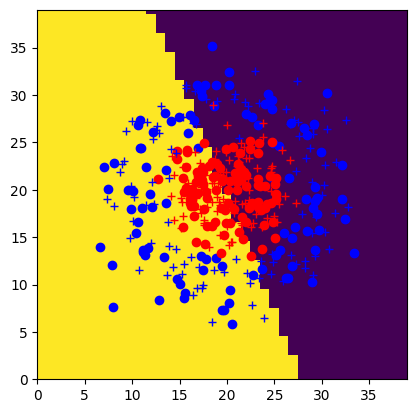

In [115]:
## Print results

Ytest_pred = svm.predict(Xtest)
accuracy = np.sum(Ytest == Ytest_pred) / len(Ytest)
print(f"Accuracy : {100 * accuracy:.2f}")
Ygrid_pred = svm.predict(Xgrid)
plot_svm_predictions(data, Ygrid_pred)

More complex kernels:


Kernel : linear
Accuracy : 62.00


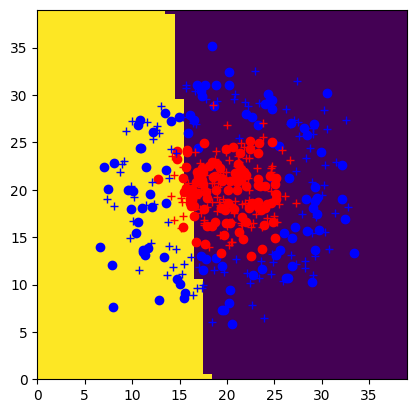

Kernel : poly
Accuracy : 54.50


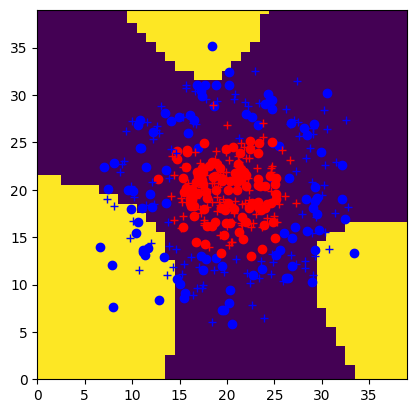

Kernel : rbf
Accuracy : 94.00


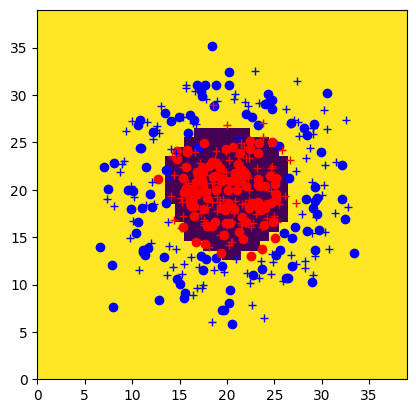

Kernel : sigmoid
Accuracy : 65.00


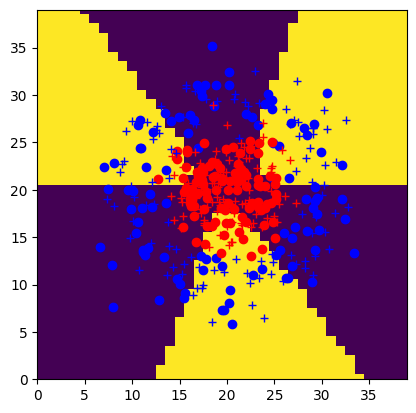

In [36]:
# compare with other kernel
list_of_kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in list_of_kernels:
    print(f"Kernel : {kernel}")
    svm = sklearn.svm.SVC(kernel=kernel)
    svm.fit(Xtrain,Ytrain)
    Ytest_pred = svm.predict(Xtest)
    accuracy = np.sum(Ytest == Ytest_pred) / len(Ytest)
    print(f"Accuracy : {100 * accuracy:.2f}")
    Ygrid_pred = svm.predict(Xgrid)
    plot_svm_predictions(data, Ygrid_pred)
    # add title
    plt.title(f"Kernel : {kernel}, Accuracy : {100 * accuracy:.2f}", fontsize=20)
    plt.show()

Experimenting with C

C : 0.1
Accuracy : 95.00


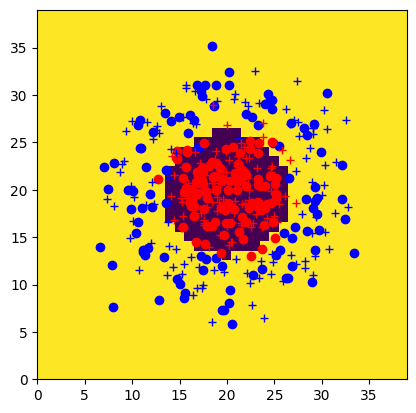

C : 1
Accuracy : 94.00


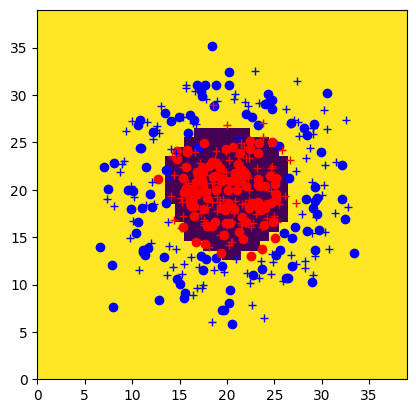

C : 10
Accuracy : 93.50


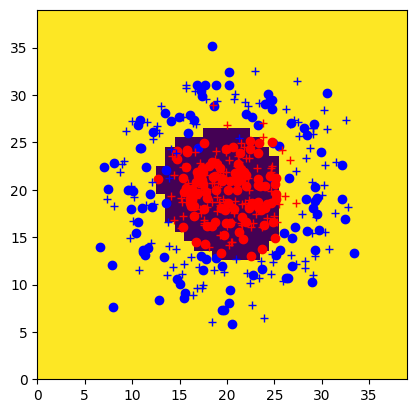

C : 100
Accuracy : 93.00


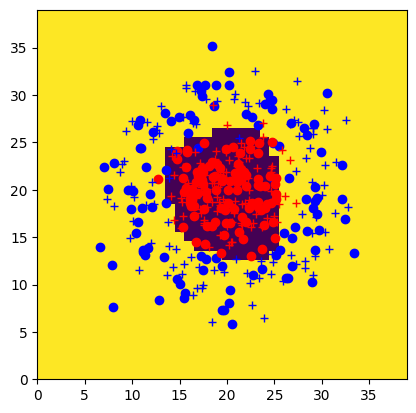

In [37]:
# see the impact of the parameter C
list_of_C = [0.1, 1, 10, 100]
for C in list_of_C:
    print(f"C : {C}")
    svm = sklearn.svm.SVC(kernel='rbf', C=C)
    svm.fit(Xtrain,Ytrain)
    Ytest_pred = svm.predict(Xtest)
    accuracy = np.sum(Ytest == Ytest_pred) / len(Ytest)
    print(f"Accuracy : {100 * accuracy:.2f}")
    Ygrid_pred = svm.predict(Xgrid)
    plot_svm_predictions(data, Ygrid_pred)
    